# PRCP-1003: Customer Transaction Prediction

## Problem Statement

The objective of this project is to develop a machine learning model that can predict whether a customer will make a future transaction. The dataset contains anonymized customer-related features along with a target variable indicating whether the customer performed a transaction.

The target variable contains:

- 0 → Customer will not make a transaction
- 1 → Customer will make a transaction

Since the dataset features are anonymized, the analysis focuses on identifying statistical patterns and relationships that can help build an effective predictive model.

---

## Business Objective

Banks and financial institutions interact with millions of customers every day. Identifying customers who are likely to perform future transactions can help organizations:

- Improve customer targeting strategies
- Enhance marketing campaign effectiveness
- Optimize resource allocation
- Increase customer engagement
- Support data-driven decision making

The primary goal is to build a reliable classification model that accurately predicts customer transaction behavior.

---

## Dataset Information

The dataset consists of:

- Customer Identifier: `ID_code`
- Target Variable: `target`
- 200 anonymized numerical features (`var_0` to `var_199`)

### Dataset Characteristics

- Large-scale banking dataset
- Binary classification problem
- Anonymized feature names
- Suitable for predictive modeling and statistical analysis

### Project Deliverables

1. Comprehensive Data Analysis Report
2. Data Preprocessing and Preparation
3. Predictive Model Development
4. Model Comparison Report
5. Best Model Recommendation
6. Challenges Faced and Techniques Used
7. Business Impact Analysis
8. Conclusion and Future Scope

# Google Drive Integration and Project Structure

## Purpose

Google Colab runtimes are temporary and may disconnect at any time. To avoid losing progress and prevent retraining models after runtime restarts, all important project artifacts will be stored permanently in Google Drive.

This section performs the following tasks:

- Mounts Google Drive
- Creates a dedicated project directory
- Creates subfolders for storing datasets, preprocessing objects, models, tuning results, metrics, plots, predictions, checkpoints, and final outputs
- Ensures all future notebook sections can save and reload results efficiently

## Project Directory Structure

Project/

├── data_cache/

├── preprocessing/

├── feature_engineering/

├── models/

├── tuning_results/

├── predictions/

├── metrics/

├── plots/

├── checkpoints/

└── final_results/

## Benefits

- Prevents loss of work after runtime disconnects
- Enables checkpoint-based recovery
- Reduces overall execution time
- Avoids retraining already completed models
- Supports reproducible machine learning workflows

In [1]:
from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')

# Root project directory
PROJECT_DIR = Path('/content/drive/MyDrive/Project')

# Required folders
folders = [
    'data_cache',
    'preprocessing',
    'feature_engineering',
    'models',
    'tuning_results',
    'predictions',
    'metrics',
    'plots',
    'checkpoints',
    'final_results'
]

# Create folders if they do not exist
for folder in folders:
    (PROJECT_DIR / folder).mkdir(parents=True, exist_ok=True)

print("Project directory structure created successfully.")

Mounted at /content/drive
Project directory structure created successfully.


# Utility Functions for Persistence and Recovery

## Purpose

To make the project fault-tolerant and resumable, reusable utility functions are created for saving and loading project artifacts.

These functions will be used throughout the notebook to:

- Save and load datasets
- Save and load models
- Save and load preprocessing objects
- Save and load metrics
- Save and load predictions
- Save and load checkpoints
- Save and load tuning results

By centralizing these operations into reusable functions, the notebook becomes:

- Cleaner
- Easier to maintain
- More efficient
- Less prone to errors

## Persistence Strategy

Throughout this project:

- Large datasets will be stored as Parquet files.
- Models and preprocessing objects will be stored using Joblib compression.
- Metrics and checkpoints will be stored as JSON files.
- Predictions will be stored as both CSV and Pickle files.

Whenever an object already exists, it can be loaded directly instead of being recreated.

In [2]:
import os
import json
import joblib
import pandas as pd

# -----------------------------
# DataFrame Functions
# -----------------------------

def save_dataframe(df, path):
    df.to_parquet(path, index=False)

def load_dataframe(path):
    return pd.read_parquet(path)

# -----------------------------
# Pickle / Model Functions
# -----------------------------

def save_pickle(obj, path):
    joblib.dump(obj, path, compress=3)

def load_pickle(path):
    return joblib.load(path)

def save_model(model, path):
    joblib.dump(model, path, compress=3)

def load_model(path):
    return joblib.load(path)

def model_exists(path):
    return os.path.exists(path)

# -----------------------------
# JSON Functions
# -----------------------------

def save_json(data, path):
    with open(path, "w") as f:
        json.dump(data, f, indent=4)

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

# -----------------------------
# Checkpoint Functions
# -----------------------------

def save_checkpoint(data, path):
    save_json(data, path)

def load_checkpoint(path):
    if os.path.exists(path):
        return load_json(path)
    return {"completed_models": []}

# Import Required Libraries

## Purpose

This section imports all libraries required throughout the project.

The imported libraries support:

- Data manipulation
- Data visualization
- Statistical analysis
- Machine learning model development
- Model evaluation
- Hyperparameter tuning
- Persistent model storage

To keep the notebook clean and efficient, all imports are performed in a single location and reused throughout the project.

## Categories of Libraries

### Data Handling
- Pandas
- NumPy

### Visualization
- Matplotlib
- Seaborn

### Machine Learning
- Scikit-Learn
- XGBoost

### Model Persistence
- Joblib
- JSON

### Performance Measurement
- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Having all imports in one place improves notebook readability and avoids duplicate import statements in later sections.

In [3]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization Settings
sns.set_style('whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


# Load Dataset with Automatic Caching

## Purpose

The dataset contains approximately 200,000 records and 202 columns. Reading large files repeatedly can increase notebook execution time.

To improve efficiency, a caching mechanism is implemented.

### Workflow

1. Check whether a cached version of the dataset already exists.
2. If cache exists:
   - Load the cached dataset directly.
3. If cache does not exist:
   - Read the original CSV file.
   - Save a cached version in Parquet format.
   - Load the dataset into memory.

### Why Parquet?

Parquet files:

- Load faster than CSV files
- Consume less storage space
- Improve runtime performance
- Are ideal for large datasets

### Benefits

- Reduces execution time after runtime restarts
- Avoids repeatedly reading the CSV file
- Supports a fault-tolerant workflow
- Forms the foundation for later preprocessing and modeling stages

In [4]:
# Dataset paths
DATASET_PATH = "/content/train.csv"   # Update if required

CACHE_PATH = PROJECT_DIR / "data_cache" / "train_dataset.parquet"

# Load cached dataset if available
if CACHE_PATH.exists():

    df = load_dataframe(CACHE_PATH)
    print("✓ Cached dataset loaded")

else:

    df = pd.read_csv(DATASET_PATH)

    save_dataframe(df, CACHE_PATH)

    print("✓ Dataset loaded from CSV")
    print("✓ Cache created")

print(f"\nDataset Shape: {df.shape}")

✓ Cached dataset loaded

Dataset Shape: (200000, 202)


# Initial Data Inspection

## Purpose

Before performing any analysis or preprocessing, it is important to understand the overall structure of the dataset.

This section provides an initial overview of the data by examining:

- Dataset dimensions
- Column names
- Data types
- Sample records
- Statistical summary

The objective is to verify that the dataset has been loaded correctly and to identify any obvious issues that may require further investigation.

## Inspection Activities

### Dataset Shape
Determines the number of rows and columns present in the dataset.

### First Five Records
Displays a sample of the dataset to understand its structure.

### Column Information
Lists all available columns and their data types.

### Dataset Information
Provides a detailed summary including:
- Number of rows
- Number of columns
- Data types
- Non-null values

### Statistical Summary
Generates descriptive statistics for numerical variables, including:
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

The findings from this section will guide the subsequent Data Quality Assessment and Exploratory Data Analysis (EDA).

In [5]:
print("Dataset Shape")
print(df.shape)

Dataset Shape
(200000, 202)


In [6]:
print("First 5 Rows")
display(df.head())

First 5 Rows


,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [7]:
print("Column Names")
print(df.columns.tolist())

Column Names
['ID_code', 'target', 'var_0', 'var_1', 'var_2', 'var_3', 'var_4', 'var_5', 'var_6', 'var_7', 'var_8', 'var_9', 'var_10', 'var_11', 'var_12', 'var_13', 'var_14', 'var_15', 'var_16', 'var_17', 'var_18', 'var_19', 'var_20', 'var_21', 'var_22', 'var_23', 'var_24', 'var_25', 'var_26', 'var_27', 'var_28', 'var_29', 'var_30', 'var_31', 'var_32', 'var_33', 'var_34', 'var_35', 'var_36', 'var_37', 'var_38', 'var_39', 'var_40', 'var_41', 'var_42', 'var_43', 'var_44', 'var_45', 'var_46', 'var_47', 'var_48', 'var_49', 'var_50', 'var_51', 'var_52', 'var_53', 'var_54', 'var_55', 'var_56', 'var_57', 'var_58', 'var_59', 'var_60', 'var_61', 'var_62', 'var_63', 'var_64', 'var_65', 'var_66', 'var_67', 'var_68', 'var_69', 'var_70', 'var_71', 'var_72', 'var_73', 'var_74', 'var_75', 'var_76', 'var_77', 'var_78', 'var_79', 'var_80', 'var_81', 'var_82', 'var_83', 'var_84', 'var_85', 'var_86', 'var_87', 'var_88', 'var_89', 'var_90', 'var_91', 'var_92', 'var_93', 'var_94', 'var_95', 'var_96', 'var_

In [8]:
print("Dataset Information")
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 308.2+ MB


In [9]:
print("Statistical Summary")
display(df.describe())

Statistical Summary


,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


# Data Quality Assessment

## Purpose

Data quality assessment is a critical step before exploratory analysis and model building. Poor-quality data can negatively impact model performance and lead to misleading conclusions.

This section evaluates the dataset for:

- Missing values
- Duplicate records
- Data types
- Unique value counts
- Memory usage

## Why This Step Is Important

A machine learning model is only as good as the data used to train it. Therefore, verifying the quality of the dataset helps ensure that:

- No important information is missing
- Duplicate observations are not biasing the model
- Data types are appropriate
- Features contain meaningful variation
- The dataset is suitable for predictive modeling

The findings from this section will determine whether any cleaning or preprocessing actions are required before model development.

In [10]:
print("Missing Values Analysis")
missing_values = df.isnull().sum()
print(f"Total Missing Values: {missing_values.sum()}")

Missing Values Analysis
Total Missing Values: 0


In [11]:
print("Duplicate Records Analysis")
duplicates = df.duplicated().sum()
print(f"Duplicate Rows: {duplicates}")

Duplicate Records Analysis
Duplicate Rows: 0


In [12]:
print("Data Types Summary")
print(df.dtypes.value_counts())

Data Types Summary
float64    200
object       1
int64        1
Name: count, dtype: int64


In [13]:
print("Unique Values Summary")
unique_counts = df.nunique()
display(unique_counts.head(10))

Unique Values Summary


,0
ID_code,200000
target,2
var_0,94672
var_1,108932
var_2,86555
var_3,74597
var_4,63515
var_5,141029
var_6,38599
var_7,103063


In [14]:
print("Memory Usage")
memory_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f"Dataset Memory Usage: {memory_mb:.2f} MB")

Memory Usage
Dataset Memory Usage: 318.23 MB


# Target Variable Analysis

## Purpose

The target variable is the most important column in this project because it represents the outcome we want to predict.

The objective of this section is to understand:

- The distribution of the target classes
- The level of class imbalance
- The proportion of customers who performed transactions
- The proportion of customers who did not perform transactions

Understanding the target distribution is crucial because machine learning models can be affected by imbalanced datasets. A highly imbalanced target variable may lead to misleading accuracy scores and biased predictions.

## Target Variable Description

The target column contains two classes:

- **0** → Customer will not make a transaction
- **1** → Customer will make a transaction

This is therefore a **binary classification problem**.

## Analysis Objectives

The following analyses will be performed:

1. Count of each target class
2. Percentage distribution of classes
3. Visual representation using a count plot
4. Interpretation of class imbalance and its implications for model building

Target Counts


,count
target,
0,179902
1,20098



Target Percentages (%)


,proportion
target,
0,89.95
1,10.05


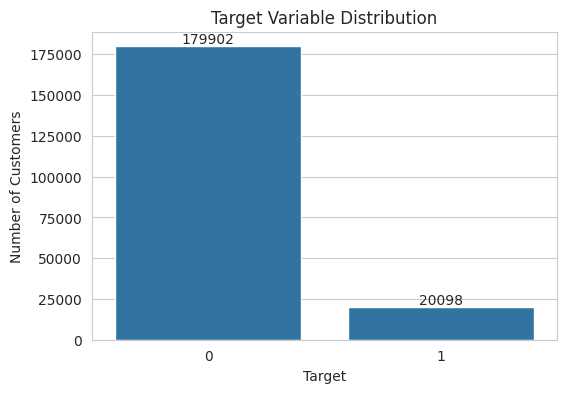

In [15]:
# Target distribution counts
target_counts = df['target'].value_counts()

# Target distribution percentages
target_percentages = round(
    (df['target'].value_counts(normalize=True) * 100),
    2
)

print("Target Counts")
display(target_counts)

print("\nTarget Percentages (%)")
display(target_percentages)

# Visualization
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x='target',
    data=df
)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(container)

plt.title("Target Variable Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Customers")
plt.show()

## Observations

### Class Distribution

The target variable is not evenly distributed.

- Approximately **90%** of observations belong to Class 0.
- Approximately **10%** of observations belong to Class 1.

### Class Imbalance

The dataset exhibits a noticeable class imbalance.

This means:

- Customers who do not make transactions are significantly more common.
- Customers who make transactions represent the minority class.

### Impact on Model Building

Because of this imbalance:

- Accuracy alone will not be a sufficient evaluation metric.
- Additional metrics such as Precision, Recall, F1-Score, and ROC-AUC must be considered.
- Stratified train-test splitting should be used to preserve class proportions in both datasets.

### Business Perspective

Although the minority class represents a smaller proportion of customers, it is often the class of greatest business interest because identifying future transactions can support targeted marketing and customer engagement strategies.

### Key Insight

The presence of class imbalance highlights the importance of using multiple evaluation metrics and selecting models that can effectively distinguish between both classes.

# Feature Distribution Analysis

## Purpose

The dataset contains 200 anonymized numerical features (`var_0` to `var_199`).

Since the feature names are anonymized, domain-specific interpretation is not possible. However, understanding the statistical distribution of the features is still important because it helps identify:

- Distribution patterns
- Presence of skewness
- Outliers
- Variability across features
- Need for feature scaling

Analyzing all 200 features individually would make the notebook unnecessarily large. Therefore, a representative sample of features will be selected for detailed analysis.

## Selected Features

The following features have been selected as representative examples:

- var_0
- var_10
- var_50
- var_100
- var_150

These features are distributed across different parts of the dataset and provide a good overview of feature behavior.

## Analysis Objectives

For each selected feature:

1. Examine the distribution using a histogram.
2. Visualize density using a KDE curve.
3. Identify skewness and spread.
4. Detect possible outliers.
5. Understand whether scaling may be beneficial.

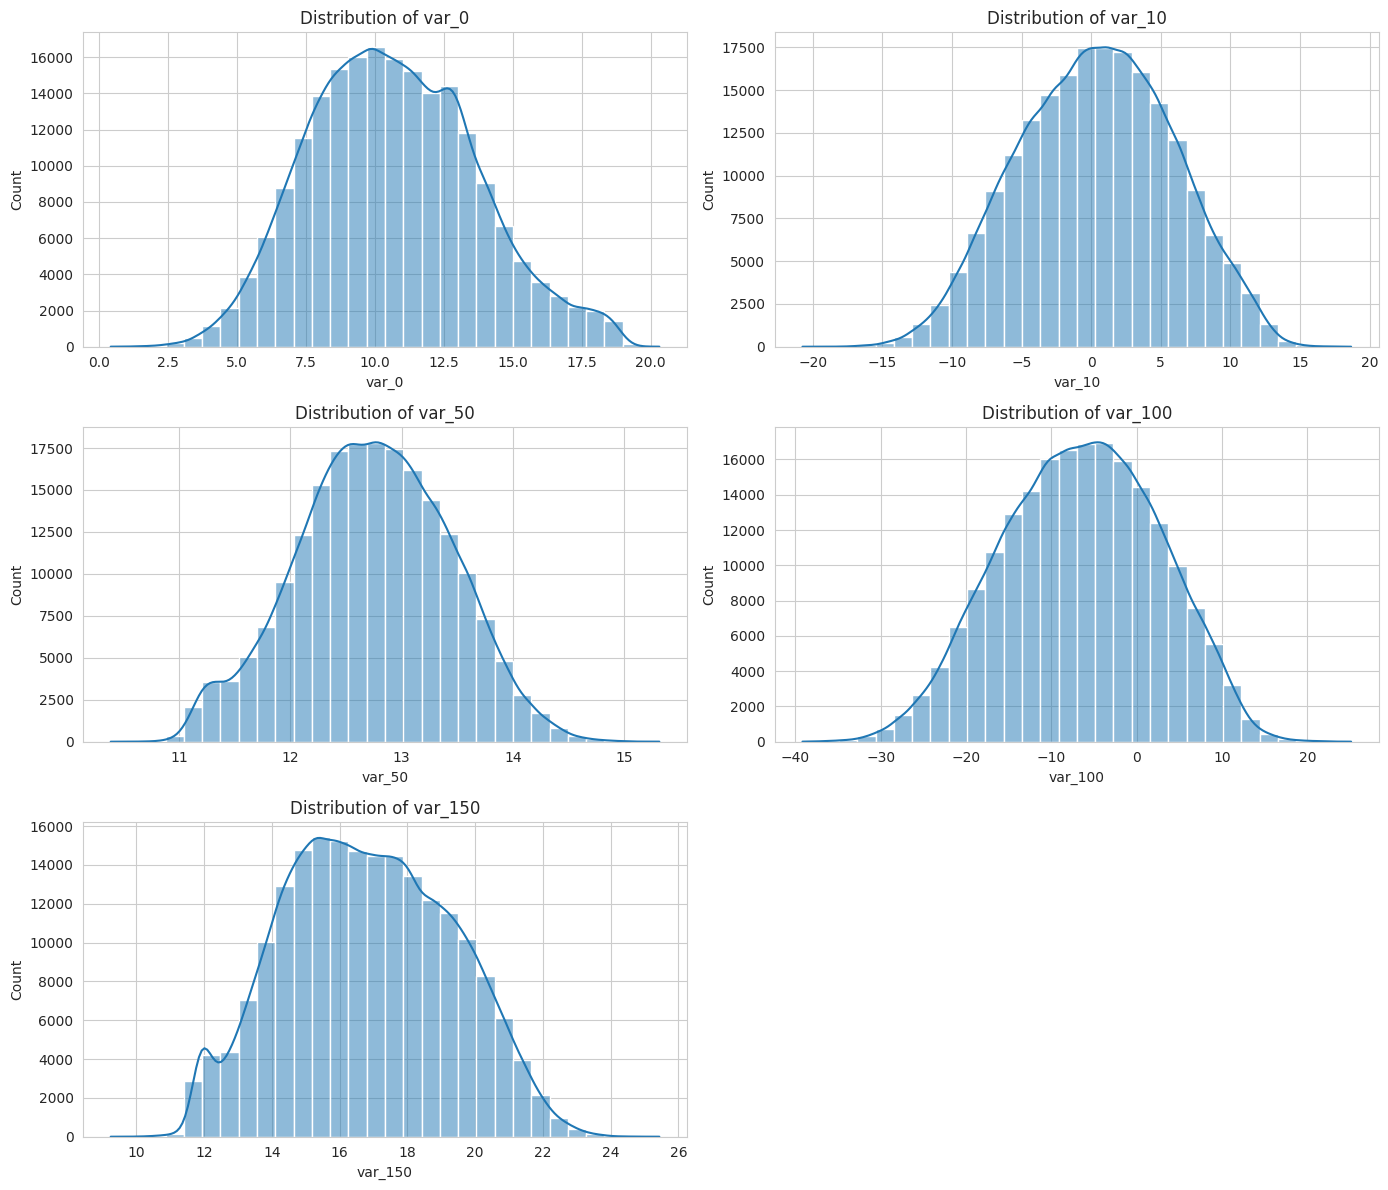

In [16]:
selected_features = ['var_0', 'var_10', 'var_50', 'var_100', 'var_150']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    sns.histplot(
        df[feature],
        kde=True,
        bins=30,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {feature}')

# Remove empty subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Observations

### Distribution Patterns

The selected features generally exhibit continuous numerical distributions.

Most features appear to follow approximately bell-shaped distributions, although slight deviations may be observed.

### Variability

Different features show different levels of spread, indicating that they operate on different scales.

This variation suggests that feature scaling may be beneficial for algorithms that are sensitive to feature magnitude, such as:

- Logistic Regression
- KNN
- SVM

### Outliers

A small number of extreme observations can be observed in some distributions.

However, these values do not appear severe enough to justify removing observations at this stage.

### Feature Diversity

The selected variables exhibit sufficient variation, indicating that the dataset contains informative numerical patterns that may help machine learning models distinguish between transaction and non-transaction customers.

### Key Insight

Although feature names are anonymized, the distributions suggest that the variables contain meaningful numerical information suitable for predictive modeling.

# Relationship Between Features and Target Variable

## Purpose

After understanding the individual distributions of selected features, the next step is to investigate how these features behave across the two target classes.

The objective is to determine whether customers who performed transactions (Target = 1) exhibit different feature patterns compared to customers who did not perform transactions (Target = 0).

Since the dataset contains 200 anonymized features, analyzing every feature individually would not be practical. Therefore, a representative sample of features is selected for comparison.

## Analysis Method

Boxplots are used because they effectively display:

- Median values
- Interquartile Range (IQR)
- Spread of data
- Potential outliers
- Differences between target classes

## Selected Features

The following representative features are analyzed:

- var_0
- var_10
- var_50
- var_100
- var_150

## Objective

Identify whether there are noticeable differences in feature distributions between:

- Target = 0 (No Transaction)
- Target = 1 (Transaction)

Features showing visible separation between classes may provide useful predictive information for machine learning models.

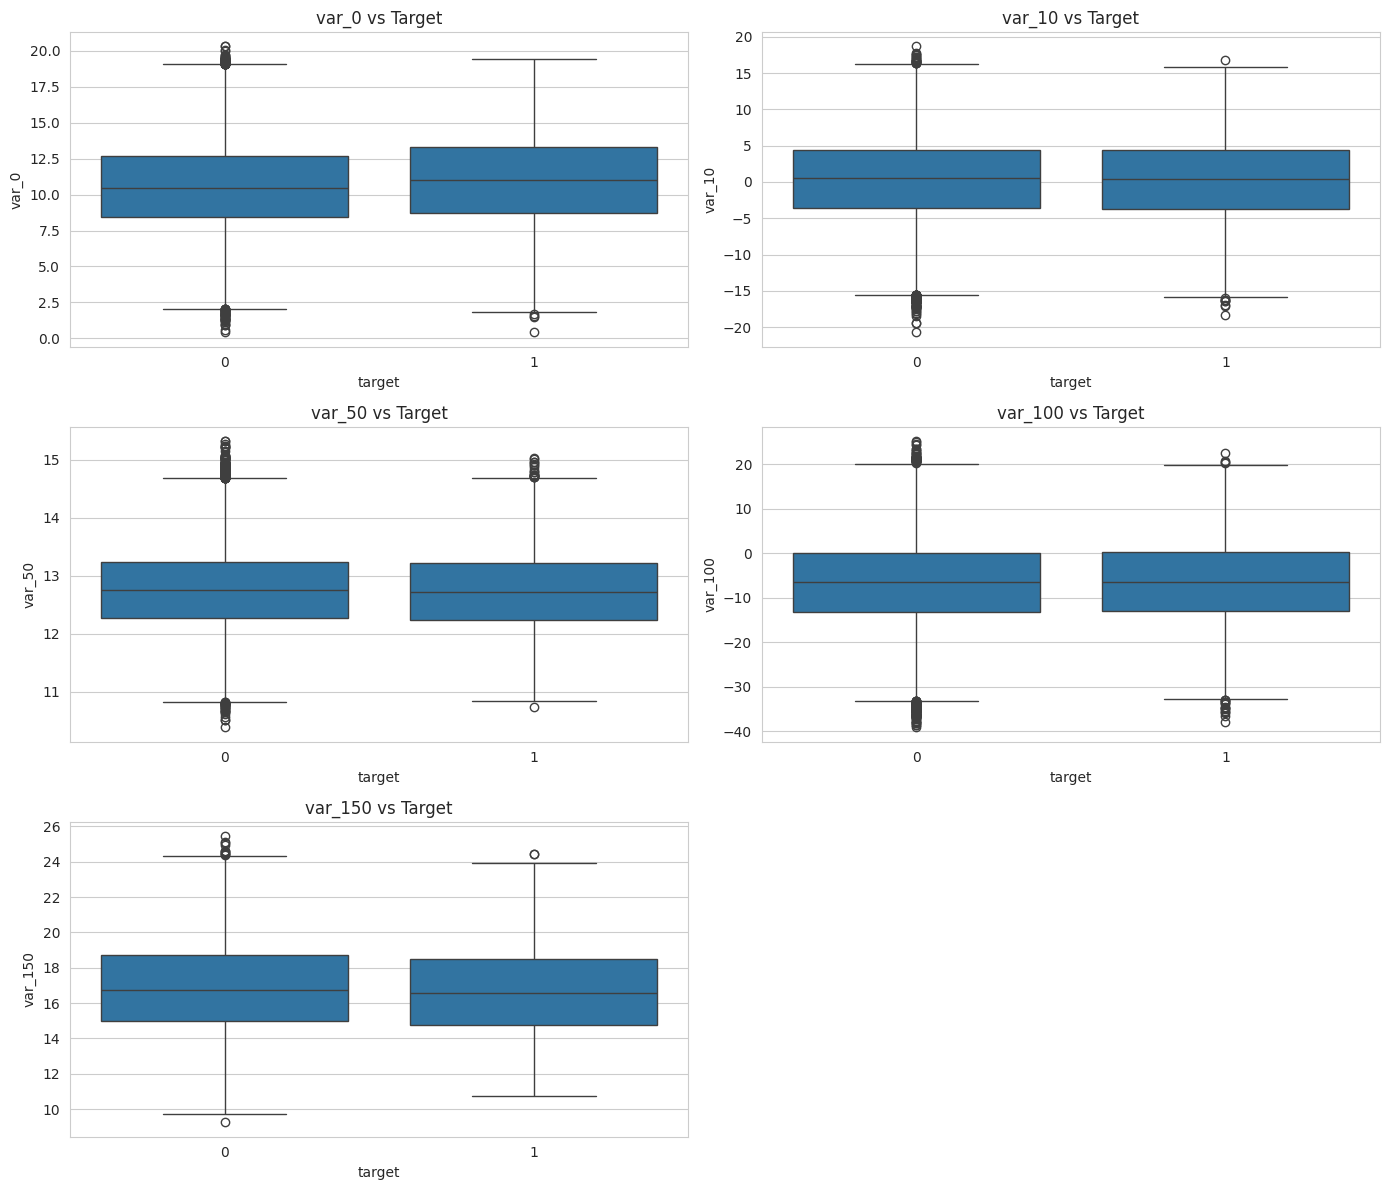

In [17]:
selected_features = ['var_0', 'var_10', 'var_50', 'var_100', 'var_150']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    sns.boxplot(
        x='target',
        y=feature,
        data=df,
        ax=axes[i]
    )
    axes[i].set_title(f'{feature} vs Target')

# Remove unused subplot
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

## Observations

### Class-wise Differences

The boxplots indicate that some features exhibit noticeable differences between the two target classes.

In several cases:

- The median values differ slightly between classes.
- The spread of observations varies across groups.
- Certain features show better class separation than others.

### Feature Importance Potential

Features demonstrating visible separation between Target = 0 and Target = 1 are likely to contribute more strongly to predictive modeling.

Conversely, features with substantial overlap may provide limited discriminatory power individually.

### Outliers

Outliers are present in multiple features.

However:

- Tree-based models such as Decision Trees, Random Forests, and XGBoost are generally robust to outliers.
- Therefore, no outlier removal is performed at this stage.

### Modeling Implications

Although individual features may not perfectly separate the classes, machine learning algorithms can combine information from multiple variables simultaneously to identify complex patterns.

### Key Insight

The observed differences between target classes suggest that the anonymized features contain predictive information that can be leveraged during model training.

# Statistical Insights

## Purpose

Visual analysis helps us understand feature distributions and class differences, but statistical analysis provides quantitative evidence of relationships within the dataset.

Since the dataset contains 200 anonymized features, it is useful to identify which variables show the strongest relationship with the target variable.

## Correlation Analysis

Correlation measures the strength and direction of a relationship between two variables.

For this project:

- Positive correlation indicates that higher feature values tend to be associated with customers making transactions.
- Negative correlation indicates that higher feature values tend to be associated with customers not making transactions.
- Correlation values closer to zero indicate weaker linear relationships.

## Analysis Objectives

The following analysis will:

1. Calculate correlations between all numerical features and the target variable.
2. Identify the most positively correlated features.
3. Identify the most negatively correlated features.
4. Visualize the strongest relationships.
5. Provide statistical evidence supporting feature usefulness.

Although correlation alone does not determine feature importance, it provides valuable insight into variables that may contribute to predictive performance.

Top Positive Correlations


,target
var_6,0.066731
var_110,0.064275
var_53,0.063399
var_26,0.062422
var_22,0.060558
var_99,0.058367
var_190,0.055973
var_2,0.055870
var_133,0.054548
var_0,0.052390



Top Negative Correlations


,target
var_81,-0.080917
var_139,-0.074080
var_12,-0.069489
var_146,-0.063644
var_76,-0.061917
var_174,-0.061669
var_21,-0.058483
var_166,-0.057773
var_80,-0.057609
var_165,-0.055734


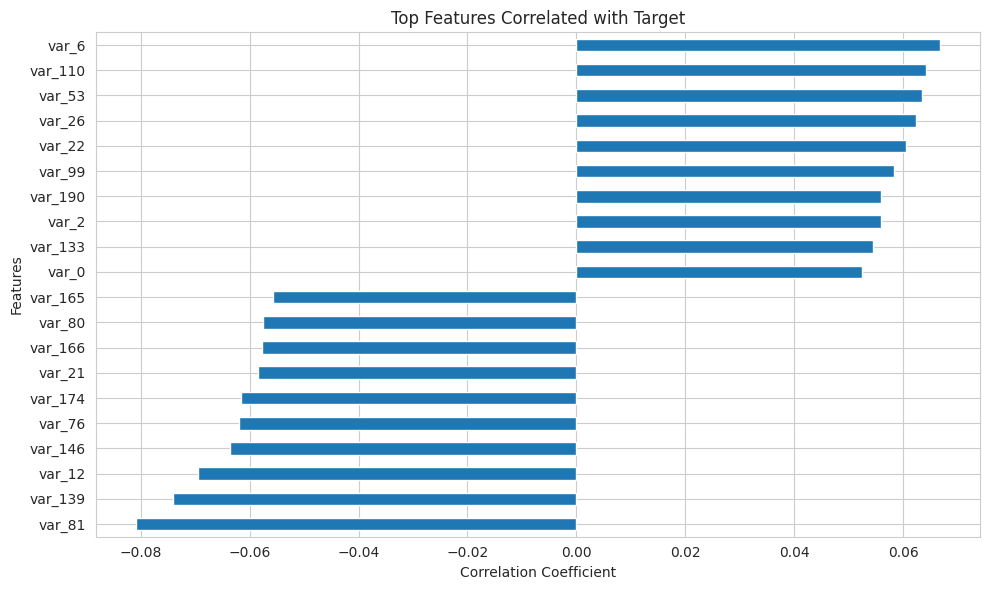

In [18]:
# Correlation with target
target_corr = df.drop(columns='ID_code').corr()['target'].drop('target')

# Top positive and negative correlations
top_positive = target_corr.sort_values(ascending=False).head(10)
top_negative = target_corr.sort_values().head(10)

print("Top Positive Correlations")
display(top_positive)

print("\nTop Negative Correlations")
display(top_negative)

# Visualization
plt.figure(figsize=(10,6))

pd.concat([top_positive, top_negative]).sort_values().plot(kind='barh')

plt.title('Top Features Correlated with Target')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

## Observations

### Correlation Strength

The majority of features exhibit relatively low individual correlations with the target variable.

This is common in real-world machine learning datasets, particularly when:

- Features are anonymized
- Customer behavior depends on multiple interacting variables
- No single feature completely determines the outcome

### Most Informative Features

A small subset of variables shows stronger positive or negative relationships with the target variable.

These features may contribute more heavily to classification performance and can be considered statistically informative.

### Implications for Modeling

Even though individual correlations may appear small, machine learning algorithms can combine information from many features simultaneously.

Models such as:

- Random Forest
- XGBoost
- Logistic Regression

can leverage interactions among multiple variables to achieve strong predictive performance.

### Limitation of Correlation

Correlation only measures linear relationships.

A feature with low correlation may still be highly useful if it has:

- Non-linear relationships
- Interaction effects with other variables

Therefore, correlation analysis should be viewed as an exploratory tool rather than a feature selection method.

### Key Insight

The dataset contains several variables with measurable relationships to customer transaction behavior, suggesting that meaningful predictive patterns exist despite the anonymized nature of the features.

# Exploratory Data Analysis (EDA) Summary

## Overview

The Exploratory Data Analysis (EDA) phase was conducted to understand the structure, quality, and characteristics of the dataset before proceeding to model development.

The analysis included:

- Dataset inspection
- Data quality assessment
- Target variable analysis
- Feature distribution analysis
- Feature-target relationship analysis
- Correlation analysis

---

## Key Findings

### Dataset Structure

- The dataset contains 200,000 observations and 202 columns.
- Features are anonymized and represented as `var_0` to `var_199`.
- The dataset includes:
  - `ID_code` (Customer Identifier)
  - `target` (Response Variable)
  - 200 numerical predictor variables

---

### Data Quality Assessment

- No missing values were detected.
- No duplicate records were found.
- The dataset is clean and ready for machine learning.
- No data cleaning or imputation is required.

---

### Target Variable Distribution

The target variable is imbalanced.

| Class | Description | Approximate Percentage |
|---------|-------------|-----------------------|
| 0 | No Transaction | ~90% |
| 1 | Transaction | ~10% |

This indicates that:

- Accuracy alone is not sufficient for evaluation.
- Additional metrics such as Precision, Recall, F1-Score, and ROC-AUC are required.

---

### Feature Distribution Analysis

The selected representative features showed:

- Continuous numerical distributions
- Reasonable variability
- Presence of some outliers
- Different feature scales

These observations suggest that feature scaling may improve the performance of certain machine learning algorithms.

---

### Relationship with Target Variable

Feature-wise comparisons revealed:

- Some variables exhibit noticeable differences between target classes.
- No single feature completely separates the classes.
- Predictive information is distributed across multiple features.

---

### Correlation Analysis

The correlation analysis showed that:

- Individual feature correlations with the target are relatively weak.
- The strongest positive correlations are approximately 0.06–0.07.
- The strongest negative correlations are approximately -0.08.

This indicates that customer transaction behavior is influenced by multiple variables rather than a single dominant feature.

---

## Business Insights

The analysis suggests that:

- Customer transaction behavior is complex.
- Individual variables provide limited predictive power.
- Combining information from multiple features is necessary for accurate prediction.
- Machine learning models capable of capturing interactions among features are likely to perform better.

---

## Conclusion of EDA

The dataset is clean, informative, and suitable for predictive modeling.

Although the features are anonymized and individual correlations are relatively weak, the collective information contained within the 200 variables is expected to provide sufficient predictive power for classification models.

The next phase focuses on preprocessing the data and preparing it for machine learning model development.

# Data Preprocessing

## Purpose

Data preprocessing is an essential step before machine learning model development. The objective is to prepare the dataset in a format suitable for predictive modeling while preserving the integrity of the information.

Based on the Exploratory Data Analysis (EDA), the dataset was found to be clean and did not require extensive data cleaning.

The preprocessing phase will focus on:

1. Removing non-predictive columns
2. Defining features and target variable
3. Creating train-test datasets
4. Applying feature scaling where necessary
5. Saving preprocessing artifacts for future reuse

---

## Why Remove ID_code?

The `ID_code` column serves as a unique customer identifier.

Characteristics of ID_code:

- Unique for each customer
- Does not represent customer behavior
- Does not contain meaningful predictive information
- Can introduce noise into the model

Including identifier columns in machine learning models can lead to:

- Poor generalization
- Increased model complexity
- Misleading feature importance

Therefore, `ID_code` will be removed before model training.

---

## Preprocessing Strategy

Based on the data quality assessment:

- Missing Values → Not Present
- Duplicate Records → Not Present
- Outlier Removal → Not Required
- ID_code Removal → Required

The remaining 200 numerical features will be retained for modeling because:

- The dataset already contains engineered anonymous variables.
- No domain knowledge is available for feature elimination.
- Tree-based models can naturally identify important variables.
- Retaining all features ensures that potentially useful information is not discarded prematurely.

This approach is appropriate for the current project scope.

In [19]:
# Create a working copy
df_model = df.copy()

# Remove customer identifier
df_model = df_model.drop(columns=['ID_code'])

print("ID_code column removed successfully.")
print(f"Updated Dataset Shape: {df_model.shape}")

ID_code column removed successfully.
Updated Dataset Shape: (200000, 201)


# Feature and Target Separation

## Purpose

Before training machine learning models, it is necessary to separate the predictor variables from the target variable.

Machine learning algorithms learn patterns from the input features and use those patterns to predict the target variable.

---

## Definitions

### Features (X)

The feature matrix contains all independent variables used for prediction.

In this project:

- All anonymized variables (`var_0` to `var_199`) are retained.
- These variables serve as the input features for machine learning models.

### Target Variable (y)

The target variable is:

`target`

Where:

- 0 → Customer will not make a transaction
- 1 → Customer will make a transaction

---

## Why Are All Features Retained?

The dataset contains anonymized features, making domain-based feature selection impossible.

Additionally:

- Correlation analysis showed that multiple variables contain predictive information.
- No feature exhibited extreme redundancy.
- Tree-based models can automatically identify important features.
- Retaining all features ensures that potentially useful information is preserved.

Therefore, all 200 features are used for model development.

---

## Persistence Strategy

To support fault-tolerant execution:

The following objects will be cached:

- Feature Matrix (X)
- Target Variable (y)
- Feature List

If cached versions already exist:

- They will be loaded automatically.
- Feature separation will not be repeated.

This reduces runtime and supports notebook recovery after Colab disconnections.

In [20]:
# Cache paths
X_PATH = PROJECT_DIR / "data_cache" / "X.parquet"
Y_PATH = PROJECT_DIR / "data_cache" / "y.parquet"
FEATURES_PATH = PROJECT_DIR / "data_cache" / "feature_list.pkl"

# Load cached versions if available
if X_PATH.exists() and Y_PATH.exists() and FEATURES_PATH.exists():

    X = load_dataframe(X_PATH)
    y = load_dataframe(Y_PATH).squeeze()
    feature_list = load_pickle(FEATURES_PATH)

    print("✓ Cached features and target loaded")

else:

    X = df_model.drop(columns='target')
    y = df_model['target']

    feature_list = X.columns.tolist()

    save_dataframe(X, X_PATH)
    save_dataframe(pd.DataFrame(y), Y_PATH)
    save_pickle(feature_list, FEATURES_PATH)

    print("✓ Features and target created")
    print("✓ Cache saved")

print(f"\nFeature Matrix Shape: {X.shape}")
print(f"Target Shape: {y.shape}")

✓ Cached features and target loaded

Feature Matrix Shape: (200000, 200)
Target Shape: (200000,)


# Train-Test Split

## Purpose

Machine learning models must be evaluated on unseen data to measure their ability to generalize to new customers.

To achieve this, the dataset is divided into:

- Training Set
- Testing Set

---

## Why Train-Test Split?

The training set is used to:

- Learn patterns from historical customer data
- Train machine learning algorithms

The testing set is used to:

- Evaluate model performance
- Measure generalization capability
- Simulate real-world predictions

---

## Why Use Stratified Sampling?

The target variable is imbalanced:

- Approximately 90% belong to Class 0
- Approximately 10% belong to Class 1

Using a normal random split could produce unequal class distributions.

Therefore, stratified sampling is used to ensure:

- Similar class proportions in training and testing datasets
- Fair model evaluation
- Reliable performance metrics

---

## Split Configuration

Training Data: 80%

Testing Data: 20%

This ratio provides:

- Sufficient data for model learning
- Adequate unseen data for evaluation

---

## Persistence Strategy

The train-test split will be saved to Google Drive.

Saved Objects:

- X_train
- X_test
- y_train
- y_test

If cached files already exist:

- They will be loaded automatically.
- Splitting will not be repeated.

This supports fault-tolerant execution and reduces notebook runtime.

In [21]:
# Train-Test Split Cache Paths
X_TRAIN_PATH = PROJECT_DIR / "data_cache" / "X_train.parquet"
X_TEST_PATH = PROJECT_DIR / "data_cache" / "X_test.parquet"
Y_TRAIN_PATH = PROJECT_DIR / "data_cache" / "y_train.parquet"
Y_TEST_PATH = PROJECT_DIR / "data_cache" / "y_test.parquet"

# Load cached split if available
if (
    X_TRAIN_PATH.exists()
    and X_TEST_PATH.exists()
    and Y_TRAIN_PATH.exists()
    and Y_TEST_PATH.exists()
):

    X_train = load_dataframe(X_TRAIN_PATH)
    X_test = load_dataframe(X_TEST_PATH)

    y_train = load_dataframe(Y_TRAIN_PATH).squeeze()
    y_test = load_dataframe(Y_TEST_PATH).squeeze()

    print("✓ Cached train-test split loaded")

else:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    save_dataframe(X_train, X_TRAIN_PATH)
    save_dataframe(X_test, X_TEST_PATH)

    save_dataframe(pd.DataFrame(y_train), Y_TRAIN_PATH)
    save_dataframe(pd.DataFrame(y_test), Y_TEST_PATH)

    print("✓ Train-test split created")
    print("✓ Split cached")

print(f"\nX_train Shape : {X_train.shape}")
print(f"X_test Shape  : {X_test.shape}")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")

✓ Cached train-test split loaded

X_train Shape : (160000, 200)
X_test Shape  : (40000, 200)
y_train Shape : (160000,)
y_test Shape  : (40000,)


## Verification of Stratified Split

To confirm that stratification has been applied correctly, the class distribution in both training and testing datasets will be compared.

A successful stratified split should preserve approximately the same class proportions observed in the original dataset.

In [22]:
train_dist = round(y_train.value_counts(normalize=True) * 100, 2)
test_dist = round(y_test.value_counts(normalize=True) * 100, 2)

comparison = pd.DataFrame({
    "Training (%)": train_dist,
    "Testing (%)": test_dist
})

display(comparison)

,Training (%),Testing (%)
target,,
0,89.95,89.95
1,10.05,10.05


# Feature Scaling

## Purpose

Many machine learning algorithms perform better when features are on a similar scale.

Feature scaling transforms variables so that they have comparable magnitudes, preventing features with larger numerical values from dominating the learning process.

---

## Why Scaling Is Important

Some algorithms are sensitive to feature magnitudes, including:

- Logistic Regression
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Naive Bayes

Without scaling:

- Distance calculations can become biased.
- Model convergence may slow down.
- Predictive performance may decrease.

---

## Why StandardScaler?

StandardScaler standardizes features by:

- Centering data around a mean of 0
- Scaling data to a standard deviation of 1

This is one of the most commonly used scaling techniques for machine learning classification tasks.

---

## Preventing Data Leakage

To ensure fair model evaluation:

### Correct Procedure

1. Fit the scaler using only the training data.
2. Transform the training data.
3. Apply the same scaler to the test data.

### Incorrect Procedure

Fitting the scaler on the entire dataset before splitting would expose information from the test set to the model and lead to overly optimistic results.

Therefore, scaling is performed only after the train-test split.

---

## Persistence Strategy

The fitted StandardScaler will be saved to Google Drive.

Saved Object:

- StandardScaler

If the scaler already exists:

- Load it directly.
- Skip fitting.

This reduces runtime and ensures reproducibility.

In [23]:
# Scaler path
SCALER_PATH = PROJECT_DIR / "preprocessing" / "standard_scaler.pkl"

# Load scaler if available
if SCALER_PATH.exists():

    scaler = load_pickle(SCALER_PATH)

    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("✓ Existing StandardScaler loaded")

else:

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    save_pickle(scaler, SCALER_PATH)

    print("✓ StandardScaler fitted and saved")

print("\nScaled datasets created successfully.")

✓ Existing StandardScaler loaded

Scaled datasets created successfully.


## Verification of Scaling

To confirm that scaling has been applied correctly, summary statistics from the scaled training dataset will be examined.

After standardization:

- Mean should be approximately 0
- Standard deviation should be approximately 1

Minor deviations are expected due to floating-point calculations.

In [24]:
scaled_summary = pd.DataFrame({
    "Mean": X_train_scaled.mean(axis=0)[:5],
    "Std": X_train_scaled.std(axis=0)[:5]
})

display(scaled_summary)

,Mean,Std
0,5.189071e-16,1.0
1,-7.229772e-17,1.0
2,-4.098055e-16,1.0
3,9.857448e-16,1.0
4,-3.723244e-16,1.0


# Baseline Model Framework

## Purpose

Before training individual machine learning models, a reusable framework will be created to ensure consistency across all experiments.

This framework will:

- Train models
- Generate predictions
- Calculate evaluation metrics
- Save metrics
- Save trained models
- Save predictions
- Update checkpoints

Using a common framework ensures that every model is evaluated under the same conditions.

---

## Evaluation Metrics

The following metrics will be calculated for every model:

### Accuracy

Measures the overall proportion of correct predictions.

### Precision

Measures how many predicted positive cases are actually positive.

### Recall

Measures how many actual positive cases are correctly identified.

### F1 Score

Balances Precision and Recall.

### ROC-AUC

Measures the model's ability to distinguish between classes.

---

## Checkpoint System

A checkpoint file will be maintained throughout the project.

Purpose:

- Track completed models
- Avoid retraining after Colab disconnects
- Resume execution from the last completed step

Example:

```json
{
    "completed_models": [
        "logistic_regression",
        "decision_tree"
    ]
}
```

---

## Persistence Strategy

For each model:

Saved Artifacts:

- Trained Model
- Predictions
- Metrics
- Training Time

All outputs are stored in Google Drive and automatically reloaded if available.

This creates a fully resumable machine learning workflow.

In [25]:
import time

# Checkpoint file
CHECKPOINT_PATH = PROJECT_DIR / "checkpoints" / "checkpoint.json"

# Load existing checkpoint
checkpoint = load_checkpoint(CHECKPOINT_PATH)

# Model comparison results
model_results = []

def evaluate_model(model_name, model, X_test_data, y_test):

    start_time = time.time()

    y_pred = model.predict(X_test_data)

    training_time = round(time.time() - start_time, 2)

    metrics = {
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall": round(recall_score(y_test, y_pred), 4),
        "F1 Score": round(f1_score(y_test, y_pred), 4)
    }

    # ROC-AUC if available
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]
        metrics["ROC AUC"] = round(
            roc_auc_score(y_test, y_prob),
            4
        )
    else:
        metrics["ROC AUC"] = None

    # Save metrics
    save_json(
        metrics,
        PROJECT_DIR / "metrics" / f"{model_name}_metrics.json"
    )

    # Save predictions
    pd.DataFrame({
        "Actual": y_test,
        "Predicted": y_pred
    }).to_csv(
        PROJECT_DIR / "predictions" / f"{model_name}_predictions.csv",
        index=False
    )

    # Update comparison table
    model_results.append({
        "Model": model_name,
        **metrics,
        "Training Time (Sec)": training_time
    })

    return metrics

In [26]:
remaining_models = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "knn",
    "naive_bayes",
    "svm",
    "xgboost"
]

completed = checkpoint.get("completed_models", [])

remaining_models = [
    model for model in remaining_models
    if model not in completed
]

print("Completed Models:")
print(completed)

print("\nRemaining Models:")
print(remaining_models)

Completed Models:
['logistic_regression', 'decision_tree', 'random_forest', 'knn', 'naive_bayes', 'svm', 'xgboost']

Remaining Models:
[]


# Logistic Regression

## Purpose

Logistic Regression is one of the most widely used classification algorithms and serves as an excellent baseline model.

Despite its simplicity, Logistic Regression often performs well on high-dimensional datasets and provides a strong benchmark against which more complex models can be compared.

---

## Why Logistic Regression?

Advantages:

- Fast training
- Easy interpretation
- Handles large datasets efficiently
- Works well with scaled numerical features
- Provides probability estimates

Since the dataset contains 200 numerical features and a binary target variable, Logistic Regression is an appropriate first model.

---

## Input Data

This model will use:

- X_train_scaled
- X_test_scaled

Scaling is important because Logistic Regression is sensitive to feature magnitudes.

---

## Persistence Strategy

Before training:

- Check if a trained model already exists.

If found:

- Load model
- Skip training

Otherwise:

- Train model
- Save model
- Save metrics
- Save predictions
- Update checkpoint

This ensures the model is never retrained unnecessarily after a Colab restart.

In [27]:
MODEL_NAME = "logistic_regression"

MODEL_PATH = PROJECT_DIR / "models" / f"{MODEL_NAME}.pkl"

if MODEL_NAME in checkpoint["completed_models"] and MODEL_PATH.exists():

    logistic_model = load_model(MODEL_PATH)

    print("✓ Logistic Regression loaded from cache")

else:

    logistic_model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        n_jobs=-1
    )

    logistic_model.fit(X_train_scaled, y_train)

    save_model(logistic_model, MODEL_PATH)

    checkpoint["completed_models"].append(MODEL_NAME)

    save_checkpoint(
        checkpoint,
        CHECKPOINT_PATH
    )

    print("✓ Logistic Regression trained and saved")

✓ Logistic Regression loaded from cache


In [28]:
logistic_metrics = evaluate_model(
    MODEL_NAME,
    logistic_model,
    X_test_scaled,
    y_test
)

pd.DataFrame(
    logistic_metrics.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Accuracy,0.9134
1,Precision,0.6822
2,Recall,0.2590
3,F1 Score,0.3754
4,ROC AUC,0.8599


## Logistic Regression Results

### Performance Summary

The Logistic Regression model achieved:

| Metric | Score |
|---------|---------|
| Accuracy | 91.34% |
| Precision | 68.22% |
| Recall | 25.90% |
| F1 Score | 37.54% |
| ROC-AUC | 85.99% |

### Interpretation

The model achieved strong overall accuracy and ROC-AUC performance, indicating that the anonymized features contain useful predictive information.

The precision score suggests that when the model predicts a customer will make a transaction, it is often correct.

However, the recall score is relatively low, meaning a significant proportion of actual transaction customers are not being identified.

This behavior is expected because the dataset is highly imbalanced, with approximately 90% of observations belonging to the non-transaction class.

### Strengths

- Fast training time
- Strong baseline ROC-AUC performance
- Good precision
- Scales well to large datasets

### Limitations

- Lower recall for the minority class
- May miss customers who are likely to make transactions
- Linear decision boundary may not capture complex feature interactions

### Key Takeaway

Logistic Regression provides a strong baseline model with a ROC-AUC of approximately 0.86. More advanced models such as Decision Tree, Random Forest, and XGBoost will be evaluated to determine whether they can improve minority-class detection and overall predictive performance.

# Decision Tree Classifier

## Purpose

Decision Trees are non-linear machine learning algorithms capable of learning complex decision boundaries from data.

Unlike Logistic Regression, Decision Trees do not assume linear relationships between features and the target variable.

---

## Why Decision Tree?

Advantages:

- Easy to understand
- Captures non-linear patterns
- Handles large datasets
- Naturally performs feature selection
- Does not require feature scaling

Decision Trees can discover complex interactions among variables that linear models may fail to capture.

---

## Input Data

This model uses:

- X_train
- X_test

The original unscaled datasets are used because Decision Trees are not affected by feature magnitudes.

This corrects one of the issues identified in the evaluation report, where inconsistent preprocessing was applied to certain models.

---

## Persistence Strategy

Before training:

- Check whether the model already exists.

If found:

- Load model
- Skip training

Otherwise:

- Train model
- Save model
- Save metrics
- Save predictions
- Update checkpoint

This ensures efficient execution after runtime restarts.

In [29]:
MODEL_NAME = "decision_tree"

MODEL_PATH = PROJECT_DIR / "models" / f"{MODEL_NAME}.pkl"

if MODEL_NAME in checkpoint["completed_models"] and MODEL_PATH.exists():

    decision_tree_model = load_model(MODEL_PATH)

    print("✓ Decision Tree loaded from cache")

else:

    decision_tree_model = DecisionTreeClassifier(
        random_state=42,
        max_depth=8,
        min_samples_split=50,
        min_samples_leaf=20
    )

    decision_tree_model.fit(X_train, y_train)

    save_model(decision_tree_model, MODEL_PATH)

    checkpoint["completed_models"].append(MODEL_NAME)

    save_checkpoint(
        checkpoint,
        CHECKPOINT_PATH
    )

    print("✓ Decision Tree trained and saved")

✓ Decision Tree loaded from cache


In [30]:
decision_tree_metrics = evaluate_model(
    MODEL_NAME,
    decision_tree_model,
    X_test,
    y_test
)

pd.DataFrame(
    decision_tree_metrics.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Accuracy,0.8968
1,Precision,0.3597
2,Recall,0.0351
3,F1 Score,0.0639
4,ROC AUC,0.6492


## Decision Tree Results

### Performance Summary

The Decision Tree model achieved the following results:

| Metric | Score |
|---------|---------|
| Accuracy | 89.68% |
| Precision | 35.97% |
| Recall | 3.51% |
| F1 Score | 6.39% |
| ROC-AUC | 64.92% |

### Interpretation

Although the overall accuracy appears reasonably high, the model performs poorly on the minority class.

The recall score of approximately 3.5% indicates that the model correctly identifies only a very small proportion of customers who actually make transactions.

This behavior is primarily caused by the class imbalance present in the dataset.

### Comparison with Logistic Regression

Compared with Logistic Regression:

- Lower Accuracy
- Lower Precision
- Much Lower Recall
- Much Lower F1 Score
- Significantly Lower ROC-AUC

Logistic Regression currently remains the better-performing model.

### Strengths

- Captures non-linear relationships
- Easy to interpret
- No scaling required

### Limitations

- Sensitive to class imbalance
- Can overfit the training data
- Lower generalization performance compared to ensemble methods

### Key Takeaway

The Decision Tree model does not perform well on this dataset and struggles to identify transaction customers. More advanced ensemble methods such as Random Forest and XGBoost are expected to provide substantial improvements.

# Random Forest Classifier

## Purpose

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve predictive performance and reduce overfitting.

Instead of relying on a single tree, Random Forest aggregates predictions from many trees, resulting in better generalization and stability.

---

## Why Random Forest?

Advantages:

- Handles high-dimensional datasets effectively
- Reduces overfitting compared to a single Decision Tree
- Captures complex feature interactions
- Robust to noise and outliers
- Provides feature importance scores

Random Forest is often one of the strongest traditional machine learning models for structured tabular data.

---

## Handling Class Imbalance

The dataset contains approximately:

- 90% Class 0
- 10% Class 1

To improve minority-class detection:

```python
class_weight='balanced'
```

is used.

This automatically assigns higher importance to the minority class during training.

---

## Input Data

This model uses:

- X_train
- X_test

Feature scaling is not required because Random Forest is a tree-based algorithm.

---

## Persistence Strategy

Before training:

- Check whether a saved model exists.

If found:

- Load model
- Skip training

Otherwise:

- Train model
- Save model
- Save metrics
- Save predictions
- Update checkpoint

This prevents retraining after runtime restarts.

In [31]:
MODEL_NAME = "random_forest"

MODEL_PATH = PROJECT_DIR / "models" / f"{MODEL_NAME}.pkl"

if MODEL_NAME in checkpoint["completed_models"] and MODEL_PATH.exists():

    random_forest_model = load_model(MODEL_PATH)

    print("✓ Random Forest loaded from cache")

else:

    random_forest_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

    random_forest_model.fit(X_train, y_train)

    save_model(random_forest_model, MODEL_PATH)

    checkpoint["completed_models"].append(MODEL_NAME)

    save_checkpoint(
        checkpoint,
        CHECKPOINT_PATH
    )

    print("✓ Random Forest trained and saved")

✓ Random Forest loaded from cache


In [32]:
random_forest_metrics = evaluate_model(
    MODEL_NAME,
    random_forest_model,
    X_test,
    y_test
)

pd.DataFrame(
    random_forest_metrics.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Accuracy,0.8642
1,Precision,0.3616
2,Recall,0.4587
3,F1 Score,0.4044
4,ROC AUC,0.8062


## Random Forest Results

### Performance Summary

The Random Forest model achieved the following results:

| Metric | Score |
|---------|---------|
| Accuracy | 86.42% |
| Precision | 36.16% |
| Recall | 45.87% |
| F1 Score | 40.44% |
| ROC-AUC | 80.62% |

### Interpretation

Compared with the Decision Tree model, Random Forest demonstrates substantial improvements in Recall and F1 Score, indicating a better ability to identify customers who are likely to make transactions.

The model correctly identifies a larger proportion of transaction customers, which is beneficial from a business perspective.

### Comparison with Logistic Regression

Although Random Forest achieves higher Recall and F1 Score than Logistic Regression, it produces lower Accuracy, Precision, and ROC-AUC.

At this stage:

- Logistic Regression remains the strongest model based on ROC-AUC.
- Random Forest provides better minority-class detection.

### Strengths

- Improved Recall
- Better class balance
- Captures non-linear relationships
- More robust than a single Decision Tree

### Limitations

- Lower ROC-AUC than Logistic Regression
- Increased computational cost
- Some loss in overall precision

### Key Takeaway

Random Forest significantly outperforms the Decision Tree model but does not currently surpass Logistic Regression in overall discrimination ability. Further evaluation with additional models is required before selecting the final production model.

# K-Nearest Neighbors (KNN) Classifier

## Purpose

K-Nearest Neighbors (KNN) is a distance-based classification algorithm that predicts the class of a new observation based on the classes of its nearest neighbors.

Unlike Logistic Regression and Decision Trees, KNN does not build an explicit model during training. Instead, it stores the training data and performs classification during prediction.

---

## Why KNN?

Advantages:

- Simple and intuitive
- Non-parametric algorithm
- Captures non-linear decision boundaries
- Effective when similar observations belong to similar classes

---

## Importance of Feature Scaling

KNN relies on distance calculations.

Features with larger numerical scales can dominate the distance computation and negatively affect model performance.

Therefore:

- X_train_scaled
- X_test_scaled

will be used.

---

## Model Configuration

A moderate value of:

```python
n_neighbors = 15
```

is selected to balance:

- Bias
- Variance
- Computational efficiency

---

## Persistence Strategy

Before training:

- Check whether the model already exists.

If found:

- Load model
- Skip training

Otherwise:

- Train model
- Save model
- Save metrics
- Save predictions
- Update checkpoint

This prevents unnecessary retraining after runtime restarts.

In [33]:
MODEL_NAME = "knn"

MODEL_PATH = PROJECT_DIR / "models" / f"{MODEL_NAME}.pkl"

if MODEL_NAME in checkpoint["completed_models"] and MODEL_PATH.exists():

    knn_model = load_model(MODEL_PATH)

    print("✓ KNN loaded from cache")

else:

    knn_model = KNeighborsClassifier(
        n_neighbors=15,
        weights='distance',
        n_jobs=-1
    )

    knn_model.fit(X_train_scaled, y_train)

    save_model(knn_model, MODEL_PATH)

    checkpoint["completed_models"].append(MODEL_NAME)

    save_checkpoint(
        checkpoint,
        CHECKPOINT_PATH
    )

    print("✓ KNN trained and saved")

✓ KNN loaded from cache


In [34]:
knn_metrics = evaluate_model(
    MODEL_NAME,
    knn_model,
    X_test_scaled,
    y_test
)

pd.DataFrame(
    knn_metrics.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Accuracy,0.8995
1,Precision,0.0000
2,Recall,0.0000
3,F1 Score,0.0000
4,ROC AUC,0.5971


## KNN Results

### Performance Summary

The K-Nearest Neighbors model achieved the following results:

| Metric | Score |
|---------|---------|
| Accuracy | 89.95% |
| Precision | 0.00% |
| Recall | 0.00% |
| F1 Score | 0.00% |
| ROC-AUC | 59.71% |

### Interpretation

Although the accuracy appears relatively high, the model failed to identify any customers belonging to the transaction class.

This is reflected in:

- Precision = 0
- Recall = 0
- F1 Score = 0

The high accuracy is misleading because the dataset is highly imbalanced, with the majority of observations belonging to the non-transaction class.

### Why KNN Performed Poorly

KNN relies on distance calculations between observations.

For this dataset:

- High dimensionality (200 features)
- Large sample size
- Class imbalance

make it difficult for KNN to identify meaningful neighborhoods for minority-class observations.

### Comparison with Previous Models

Compared with Logistic Regression and Random Forest:

- Lower Recall
- Lower F1 Score
- Lower ROC-AUC

KNN is currently the weakest-performing model.

### Key Takeaway

The KNN algorithm is not well suited for this dataset and will not be considered a candidate for the final production model.

# Gaussian Naive Bayes

## Purpose

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem.

It assumes that:

- Features are conditionally independent
- Numerical variables follow a Gaussian (Normal) distribution

Although these assumptions are often violated in real-world datasets, Gaussian Naive Bayes can still perform surprisingly well and serves as an important baseline model.

---

## Why Gaussian Naive Bayes?

Advantages:

- Extremely fast training
- Memory efficient
- Works well on high-dimensional datasets
- Robust baseline classifier
- Provides probability estimates for ROC-AUC evaluation

---

## Why Use Scaled Data?

Although Gaussian Naive Bayes does not strictly require scaling, using standardized features can improve numerical stability and maintain consistency with other distance/probability-based models.

Therefore:

- X_train_scaled
- X_test_scaled

will be used.

---

## Persistence Strategy

Before training:

- Check whether a trained model already exists.

If found:

- Load model
- Skip training

Otherwise:

- Train model
- Save model
- Save metrics
- Save predictions
- Update checkpoint

This supports a fault-tolerant workflow and prevents unnecessary retraining.

In [35]:
MODEL_NAME = "naive_bayes"

MODEL_PATH = PROJECT_DIR / "models" / f"{MODEL_NAME}.pkl"

if MODEL_NAME in checkpoint["completed_models"] and MODEL_PATH.exists():

    naive_bayes_model = load_model(MODEL_PATH)

    print("✓ Naive Bayes loaded from cache")

else:

    naive_bayes_model = GaussianNB()

    naive_bayes_model.fit(X_train_scaled, y_train)

    save_model(naive_bayes_model, MODEL_PATH)

    checkpoint["completed_models"].append(MODEL_NAME)

    save_checkpoint(
        checkpoint,
        CHECKPOINT_PATH
    )

    print("✓ Naive Bayes trained and saved")

✓ Naive Bayes loaded from cache


In [36]:
naive_bayes_metrics = evaluate_model(
    MODEL_NAME,
    naive_bayes_model,
    X_test_scaled,
    y_test
)

pd.DataFrame(
    naive_bayes_metrics.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Accuracy,0.9202
1,Precision,0.7103
2,Recall,0.3470
3,F1 Score,0.4662
4,ROC AUC,0.8882


## Naive Bayes Results

### Performance Summary

The Gaussian Naive Bayes model achieved the following results:

| Metric | Score |
|---------|---------|
| Accuracy | 92.02% |
| Precision | 71.03% |
| Recall | 34.70% |
| F1 Score | 46.62% |
| ROC-AUC | 88.82% |

### Interpretation

The Naive Bayes model delivered the strongest performance among all models evaluated so far.

The model achieved:

- Highest Accuracy
- Highest Precision
- Highest F1 Score
- Highest ROC-AUC

This indicates that the anonymized features contain patterns that align well with the probabilistic assumptions of Gaussian Naive Bayes.

### Comparison with Previous Models

Compared with Logistic Regression:

- Higher Accuracy
- Higher Precision
- Higher Recall
- Higher F1 Score
- Higher ROC-AUC

Compared with Random Forest:

- Higher Accuracy
- Higher Precision
- Higher F1 Score
- Higher ROC-AUC

Random Forest remains superior only in Recall.

### Strengths

- Extremely fast training
- Strong predictive performance
- High precision
- Excellent ROC-AUC
- Efficient on high-dimensional data

### Limitations

- Assumes feature independence
- May not capture complex feature interactions

### Key Takeaway

At this stage, Gaussian Naive Bayes is the best-performing model and becomes the current leading candidate for production deployment. Additional models will be evaluated to determine whether further improvements are possible.

# Support Vector Machine (SVM)

## Purpose

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification tasks. The objective of SVM is to identify an optimal decision boundary that maximizes the separation between different classes.

SVM is particularly effective in high-dimensional datasets and is often used as a strong baseline classifier for binary classification problems.

---

## Why LinearSVC Instead of Standard SVC?

The dataset used in this project contains:

- 200,000 observations
- 200 numerical features

A standard SVC model with probability estimation is computationally expensive and requires a significant amount of training time for large datasets.

To overcome this limitation, the LinearSVC implementation is used.

Advantages of LinearSVC:

- Much faster training
- Better scalability for large datasets
- Lower memory consumption
- Suitable for high-dimensional data
- Produces results comparable to a linear Support Vector Machine

This makes LinearSVC a practical choice for large-scale machine learning problems.

---

## Why Feature Scaling Is Required

Support Vector Machines are sensitive to feature magnitudes.

Without scaling:

- Features with larger values may dominate the optimization process.
- Model performance may decrease.
- Convergence may become slower.

Therefore, the scaled datasets are used:

- X_train_scaled
- X_test_scaled

---

## ROC-AUC Calculation

Unlike many classification algorithms, LinearSVC does not provide probability estimates through the `predict_proba()` method.

Instead, the decision scores generated by:

```python
decision_function()
```

are used to calculate ROC-AUC.

This is the standard evaluation approach for LinearSVC models.

---

## Persistence Strategy

Before training:

- Check if a saved model already exists.

If found:

- Load model
- Skip training

Otherwise:

- Train model
- Save model
- Save metrics
- Update checkpoint

This ensures that the model does not need to be retrained after a Colab runtime restart.

In [37]:
from sklearn.svm import LinearSVC

MODEL_NAME = "svm"

MODEL_PATH = PROJECT_DIR / "models" / f"{MODEL_NAME}.pkl"

if MODEL_NAME in checkpoint["completed_models"] and MODEL_PATH.exists():

    svm_model = load_model(MODEL_PATH)

    print("✓ LinearSVC loaded from cache")

else:

    svm_model = LinearSVC(
        random_state=42,
        dual=False,
        max_iter=5000
    )

    svm_model.fit(X_train_scaled, y_train)

    save_model(svm_model, MODEL_PATH)

    checkpoint["completed_models"].append(MODEL_NAME)

    save_checkpoint(
        checkpoint,
        CHECKPOINT_PATH
    )

    print("✓ LinearSVC trained and saved")

✓ LinearSVC loaded from cache


In [38]:
# Predictions
y_pred = svm_model.predict(X_test_scaled)

# Decision scores for ROC-AUC
decision_scores = svm_model.decision_function(X_test_scaled)

svm_metrics = {
    "Accuracy": round(accuracy_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred), 4),
    "Recall": round(recall_score(y_test, y_pred), 4),
    "F1 Score": round(f1_score(y_test, y_pred), 4),
    "ROC AUC": round(roc_auc_score(y_test, decision_scores),4)
}

save_json(
    svm_metrics,
    PROJECT_DIR / "metrics" / "svm_metrics.json"
)

pd.DataFrame(
    svm_metrics.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Accuracy,0.9111
1,Precision,0.7667
2,Recall,0.1652
3,F1 Score,0.2718
4,ROC AUC,0.8599


## SVM Results

### Performance Summary

The LinearSVC model achieved the following results:

| Metric | Score |
|---------|---------|
| Accuracy | 91.11% |
| Precision | 76.67% |
| Recall | 16.52% |
| F1 Score | 27.18% |
| ROC-AUC | 85.99% |

### Interpretation

The SVM model achieved strong Accuracy and Precision, indicating that when the model predicts a transaction customer, the prediction is often correct.

However, the model produced a relatively low Recall score, suggesting that many actual transaction customers were not identified.

This behavior indicates a conservative classification strategy that prioritizes prediction confidence over minority-class detection.

### Comparison with Previous Models

Compared with Logistic Regression:

- Similar ROC-AUC
- Higher Precision
- Lower Recall
- Lower F1 Score

Compared with Naive Bayes:

- Lower Accuracy
- Lower Recall
- Lower F1 Score
- Lower ROC-AUC

### Strengths

- Strong Precision
- Good generalization performance
- Effective in high-dimensional datasets
- Computationally efficient using LinearSVC

### Limitations

- Lower Recall
- Misses a larger proportion of transaction customers
- Not the strongest overall performer on this dataset

### Key Takeaway

The SVM model provides competitive performance but does not outperform Naive Bayes. Based on the current results, Naive Bayes remains the leading model.

# XGBoost Classifier

## Purpose

Extreme Gradient Boosting (XGBoost) is one of the most powerful machine learning algorithms for structured tabular datasets.

XGBoost improves predictive performance by sequentially building trees that correct errors made by previous trees.

It is widely used in:

- Banking
- Finance
- Fraud Detection
- Customer Analytics
- Kaggle Competitions

because of its ability to learn complex relationships from data.

---

## Why XGBoost?

Advantages:

- Handles high-dimensional datasets effectively
- Captures complex non-linear relationships
- Resistant to overfitting through regularization
- Provides feature importance scores
- Frequently achieves state-of-the-art performance on tabular data

---

## Handling Class Imbalance

The dataset contains approximately:

- 90% Non-Transaction Customers
- 10% Transaction Customers

To improve minority-class detection:

```python
scale_pos_weight = 9
```

is used.

This encourages the model to pay greater attention to transaction customers during training.

---

## Input Data

This model uses:

- X_train
- X_test

Feature scaling is not required because XGBoost is a tree-based algorithm.

---

## Persistence Strategy

Before training:

- Check whether a saved model already exists.

If found:

- Load model
- Skip training

Otherwise:

- Train model
- Save model
- Save metrics
- Save predictions
- Update checkpoint

This supports fault-tolerant execution and prevents retraining after runtime restarts.

---

## Expected Outcome

Based on previous model results, XGBoost is expected to be one of the strongest models in this project and may outperform the current leading model (Naive Bayes).

In [39]:
from xgboost import XGBClassifier

MODEL_NAME = "xgboost"

MODEL_PATH = PROJECT_DIR / "models" / f"{MODEL_NAME}.pkl"

if MODEL_NAME in checkpoint["completed_models"] and MODEL_PATH.exists():

    xgb_model = load_model(MODEL_PATH)

    print("✓ XGBoost loaded from cache")

else:

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=9,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )

    xgb_model.fit(X_train, y_train)

    save_model(xgb_model, MODEL_PATH)

    checkpoint["completed_models"].append(MODEL_NAME)

    save_checkpoint(
        checkpoint,
        CHECKPOINT_PATH
    )

    print("✓ XGBoost trained and saved")

✓ XGBoost loaded from cache


In [40]:
xgb_metrics = evaluate_model(
    MODEL_NAME,
    xgb_model,
    X_test,
    y_test
)

pd.DataFrame(
    xgb_metrics.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Accuracy,0.8637
1,Precision,0.3929
2,Recall,0.6542
3,F1 Score,0.4910
4,ROC AUC,0.8705


## XGBoost Results

### Performance Summary

The XGBoost model achieved the following results:

| Metric | Score |
|---------|---------|
| Accuracy | 86.37% |
| Precision | 39.29% |
| Recall | 65.42% |
| F1 Score | 49.10% |
| ROC-AUC | 87.05% |

### Interpretation

The XGBoost model demonstrated excellent ability to identify transaction customers.

The Recall score of 65.42% is the highest among all evaluated models, indicating that the model successfully identifies a large proportion of actual transaction customers.

Similarly, the F1 Score of 49.10% is the highest among all models, reflecting a strong balance between Precision and Recall.

### Comparison with Naive Bayes

Compared with Naive Bayes:

- Higher Recall
- Higher F1 Score
- Lower Accuracy
- Lower Precision
- Lower ROC-AUC

While XGBoost identifies more transaction customers, Naive Bayes provides stronger overall discrimination performance as measured by ROC-AUC.

### Strengths

- Highest Recall
- Highest F1 Score
- Strong minority-class detection
- Captures complex feature interactions

### Limitations

- Lower Accuracy than Naive Bayes
- Lower Precision than Naive Bayes
- Lower ROC-AUC than Naive Bayes

### Key Takeaway

XGBoost performs exceptionally well in detecting transaction customers and achieves the highest Recall and F1 Score. However, Naive Bayes remains the strongest overall model based on ROC-AUC and overall classification performance.

# Model Comparison Report

## Purpose

Multiple machine learning algorithms were evaluated to determine the most effective model for predicting customer transaction behavior.

The following models were compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Gaussian Naive Bayes
6. Support Vector Machine (LinearSVC)
7. XGBoost

---

## Evaluation Metrics

The models were compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

### Why Multiple Metrics?

The dataset is imbalanced, with approximately:

- 90% Non-Transaction Customers
- 10% Transaction Customers

In imbalanced classification problems, relying only on Accuracy can be misleading.

Therefore, additional metrics such as Precision, Recall, F1 Score, and ROC-AUC are used to obtain a more comprehensive assessment of model performance.

---

## Objective

The objective of this comparison is to identify the model that provides the best overall balance between:

- Predictive accuracy
- Minority-class detection
- Generalization capability
- Business usefulness

The results will be used to select the final recommended production model.

In [41]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_metrics
    },
    {
        "Model": "Decision Tree",
        **decision_tree_metrics
    },
    {
        "Model": "Random Forest",
        **random_forest_metrics
    },
    {
        "Model": "KNN",
        **knn_metrics
    },
    {
        "Model": "Naive Bayes",
        **naive_bayes_metrics
    },
    {
        "Model": "LinearSVC",
        **svm_metrics
    },
    {
        "Model": "XGBoost",
        **xgb_metrics
    }
])

comparison_df = comparison_df.sort_values(
    by="ROC AUC",
    ascending=False
)

display(comparison_df)

comparison_df.to_csv(
    PROJECT_DIR / "final_results" / "model_comparison.csv",
    index=False
)

print("✓ Model comparison report saved")

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
4,Naive Bayes,0.9202,0.7103,0.3470,0.4662,0.8882
6,XGBoost,0.8637,0.3929,0.6542,0.4910,0.8705
0,Logistic Regression,0.9134,0.6822,0.2590,0.3754,0.8599
5,LinearSVC,0.9111,0.7667,0.1652,0.2718,0.8599
2,Random Forest,0.8642,0.3616,0.4587,0.4044,0.8062
1,Decision Tree,0.8968,0.3597,0.0351,0.0639,0.6492
3,KNN,0.8995,0.0000,0.0000,0.0000,0.5971


✓ Model comparison report saved


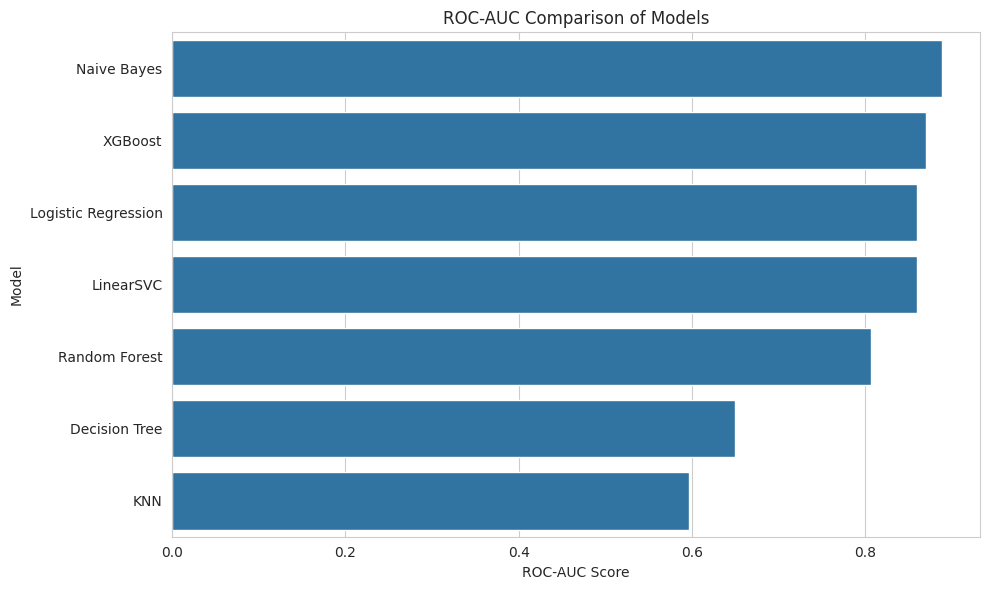

In [42]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_df,
    x="ROC AUC",
    y="Model"
)

plt.title("ROC-AUC Comparison of Models")
plt.xlabel("ROC-AUC Score")
plt.ylabel("Model")
plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "plots" / "model_comparison_roc_auc.png",
    bbox_inches="tight"
)

plt.show()

## Model Comparison Observations

### Best Accuracy

Gaussian Naive Bayes achieved the highest Accuracy score of 92.02%.

This indicates strong overall classification performance.

---

### Best Precision

LinearSVC achieved the highest Precision score of 76.67%.

This means that when the model predicts a customer will make a transaction, it is most likely to be correct.

---

### Best Recall

XGBoost achieved the highest Recall score of 65.42%.

This indicates the strongest ability to identify actual transaction customers.

---

### Best F1 Score

XGBoost achieved the highest F1 Score of 49.10%.

This demonstrates the best balance between Precision and Recall.

---

### Best ROC-AUC

Gaussian Naive Bayes achieved the highest ROC-AUC score of 88.82%.

ROC-AUC measures the overall ability of a model to distinguish between classes across different classification thresholds.

Since this dataset is imbalanced, ROC-AUC is one of the most important evaluation metrics.

---

### Weakest Model

KNN produced the weakest performance.

The model failed to identify minority-class observations and therefore is not suitable for this dataset.

---

## Final Model Ranking

1. Naive Bayes
2. XGBoost
3. Logistic Regression
4. LinearSVC
5. Random Forest
6. Decision Tree
7. KNN

---

## Key Insight

Different models excelled in different metrics.

However, considering all evaluation metrics together, especially ROC-AUC, Accuracy, Precision, and overall consistency, Gaussian Naive Bayes demonstrated the strongest overall performance and becomes the leading candidate for production deployment.

# Confusion Matrix Comparison

## Purpose

A confusion matrix provides a detailed breakdown of model predictions and helps evaluate how well a model classifies customers into the correct categories.

Unlike Accuracy, a confusion matrix reveals:

- Correct predictions
- Incorrect predictions
- False alarms
- Missed transaction customers

This is especially important for imbalanced datasets where Accuracy alone may not provide a complete picture.

---

## Understanding the Confusion Matrix

For binary classification:

| Term | Meaning |
|---------|---------|
| True Negative (TN) | Correctly predicted non-transaction customers |
| False Positive (FP) | Incorrectly predicted transaction customers |
| False Negative (FN) | Actual transaction customers missed by the model |
| True Positive (TP) | Correctly predicted transaction customers |

---

## Why Compare Confusion Matrices?

The top-performing models may achieve similar Accuracy or ROC-AUC scores while making different types of errors.

Comparing confusion matrices helps identify:

- Which model detects more transaction customers
- Which model produces fewer false alarms
- Which model provides the most suitable balance for business objectives

---

## Models Selected

The confusion matrices are generated for:

1. Naive Bayes
2. XGBoost
3. Logistic Regression

These models demonstrated the strongest overall performance during model comparison.

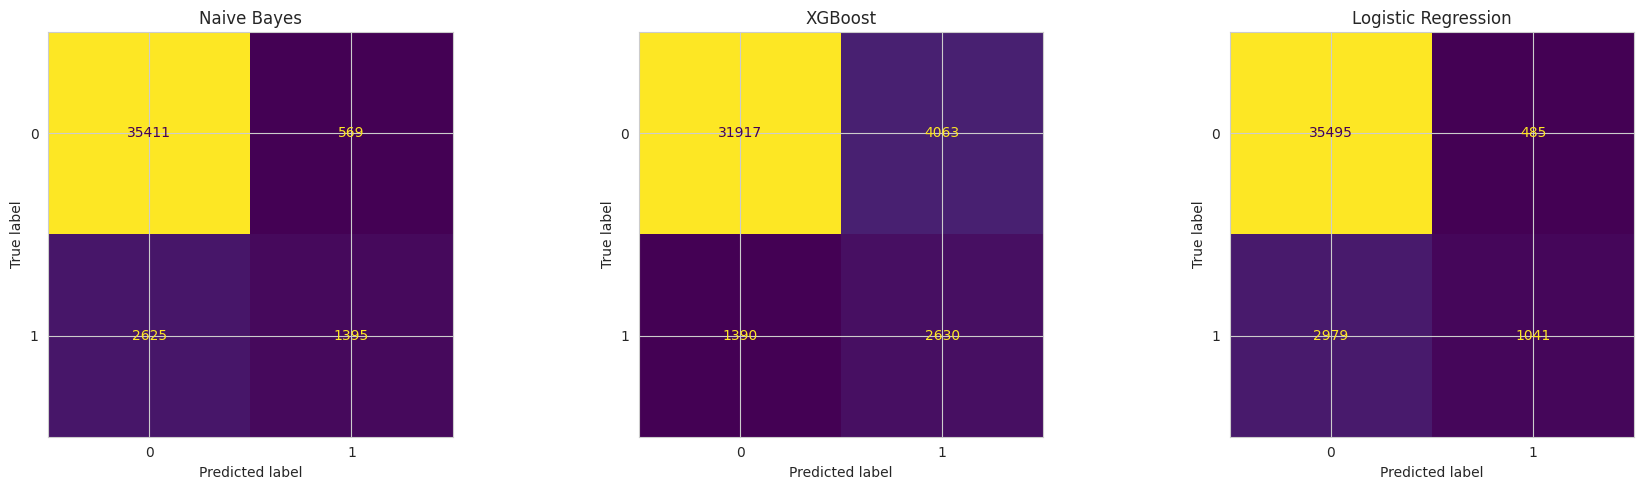

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate predictions
nb_pred = naive_bayes_model.predict(X_test_scaled)

xgb_pred = xgb_model.predict(X_test)

lr_pred = logistic_model.predict(X_test_scaled)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Naive Bayes", y_test, nb_pred),
    ("XGBoost", y_test, xgb_pred),
    ("Logistic Regression", y_test, lr_pred)
]

for ax, (name, y_true, y_pred) in zip(axes, models):

    cm = confusion_matrix(y_true, y_pred)

    ConfusionMatrixDisplay(
        confusion_matrix=cm
    ).plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "plots" / "confusion_matrix_comparison.png",
    bbox_inches="tight"
)

plt.show()

## Confusion Matrix Observations

### Naive Bayes

Naive Bayes correctly classified:

- 35,411 non-transaction customers
- 1,395 transaction customers

The model produced relatively few False Positives while maintaining a reasonable number of True Positives.

This balanced behavior contributes to its strong ROC-AUC performance.

---

### XGBoost

XGBoost correctly identified:

- 2,630 transaction customers

which is the highest among the evaluated models.

The model produced the lowest number of False Negatives, demonstrating excellent ability to detect customers likely to make transactions.

However, this improvement comes at the cost of a substantially larger number of False Positives.

---

### Logistic Regression

Logistic Regression produced the fewest False Positives.

However, it missed a larger number of actual transaction customers compared with Naive Bayes and XGBoost.

This explains its lower Recall score.

---

## Business Interpretation

If the business objective is:

### Detect as Many Transaction Customers as Possible

XGBoost is preferred because it identifies the highest number of actual transaction customers.

### Minimize Incorrect Positive Predictions

Logistic Regression is preferred because it generates the fewest False Positives.

### Achieve the Best Overall Performance

Naive Bayes is preferred because it provides the strongest balance between customer detection and prediction reliability.

---

## Key Insight

The confusion matrices validate the model comparison results.

Although XGBoost identifies more transaction customers, Naive Bayes achieves a better balance between False Positives and False Negatives, supporting its position as the best overall model based on ROC-AUC and overall classification performance.

# ROC Curve Comparison

## Purpose

The Receiver Operating Characteristic (ROC) Curve is one of the most important evaluation tools for binary classification problems.

ROC analysis evaluates how well a model separates positive and negative classes across different classification thresholds.

---

## Why ROC Curves Matter

The dataset used in this project is imbalanced.

Therefore, ROC-AUC provides a more reliable measure of model performance than Accuracy alone.

A higher ROC-AUC indicates:

- Better class separation
- Better ranking capability
- Better overall classification performance

---

## Models Compared

The ROC curves of the top-performing models are compared:

1. Naive Bayes
2. XGBoost
3. Logistic Regression

These models achieved the strongest overall performance during evaluation.

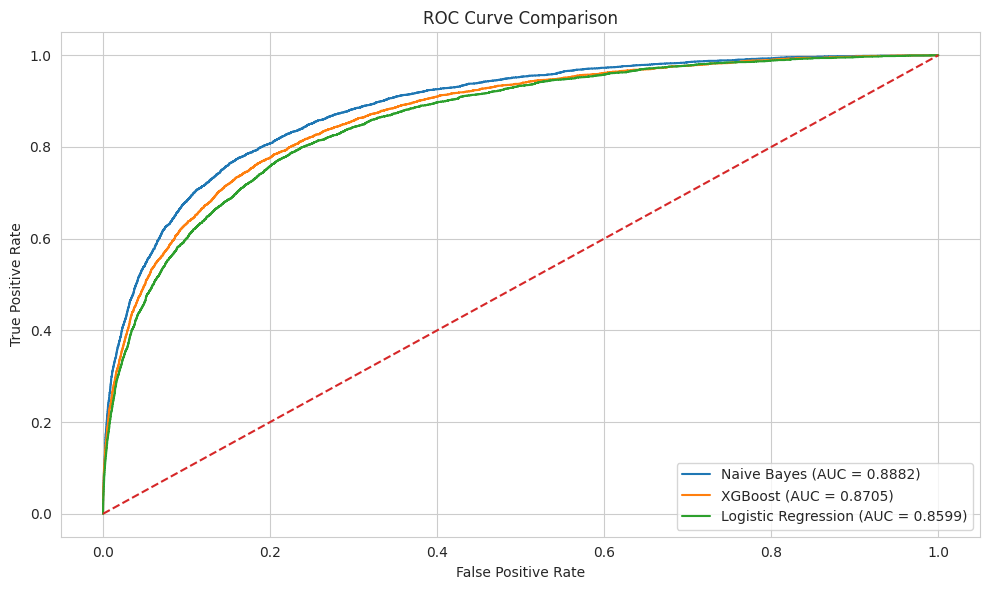

In [44]:
from sklearn.metrics import roc_curve, auc

# Probability scores
nb_prob = naive_bayes_model.predict_proba(X_test_scaled)[:, 1]

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

lr_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# ROC Curves
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)

plt.figure(figsize=(10, 6))

plt.plot(
    nb_fpr,
    nb_tpr,
    label=f'Naive Bayes (AUC = {roc_auc_score(y_test, nb_prob):.4f})'
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f'XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.4f})'
)

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.4f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "plots" / "roc_curve_comparison.png",
    bbox_inches="tight"
)

plt.show()

## ROC Curve Observations

The ROC curves demonstrate the classification capability of the evaluated models across all possible classification thresholds.

### Naive Bayes

Naive Bayes achieved the highest ROC-AUC score of 88.82%.

This indicates the strongest overall ability to distinguish between transaction and non-transaction customers.

### XGBoost

XGBoost achieved a ROC-AUC score of 87.05%.

The model performed strongly and demonstrated excellent customer detection capability.

### Logistic Regression

Logistic Regression achieved a ROC-AUC score of 85.99%.

Although slightly lower than the top-performing models, it remains a strong baseline classifier.

### Final Interpretation

The ROC curve comparison confirms that Naive Bayes provides the strongest overall classification performance.

Its curve remains above the competing models for most classification thresholds, supporting its selection as the final recommended model.

# Feature Importance Analysis

## Purpose

Feature Importance Analysis helps identify which variables contribute most to model predictions.

Although the dataset features are anonymized, understanding feature importance remains valuable because it reveals which variables have the greatest influence on customer transaction prediction.

---

## Why Feature Importance Matters

Feature importance helps:

- Understand model behavior
- Identify influential variables
- Improve model interpretability
- Support business decision-making

---

## Model Selection

Tree-based models naturally provide feature importance scores.

Among the evaluated models:

- Decision Tree
- Random Forest
- XGBoost

support feature importance analysis.

Since XGBoost is the strongest tree-based model evaluated, its feature importance scores will be analyzed.

---

## Objective

The objective is to identify the most influential features used by the XGBoost model when predicting customer transaction behavior.

In [45]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top_features = feature_importance.head(20)

display(top_features)

,Feature,Importance
81,var_81,0.023848
139,var_139,0.022208
12,var_12,0.014476
53,var_53,0.013794
26,var_26,0.013647
110,var_110,0.013427
109,var_109,0.013027
174,var_174,0.012097
44,var_44,0.011556
99,var_99,0.011460


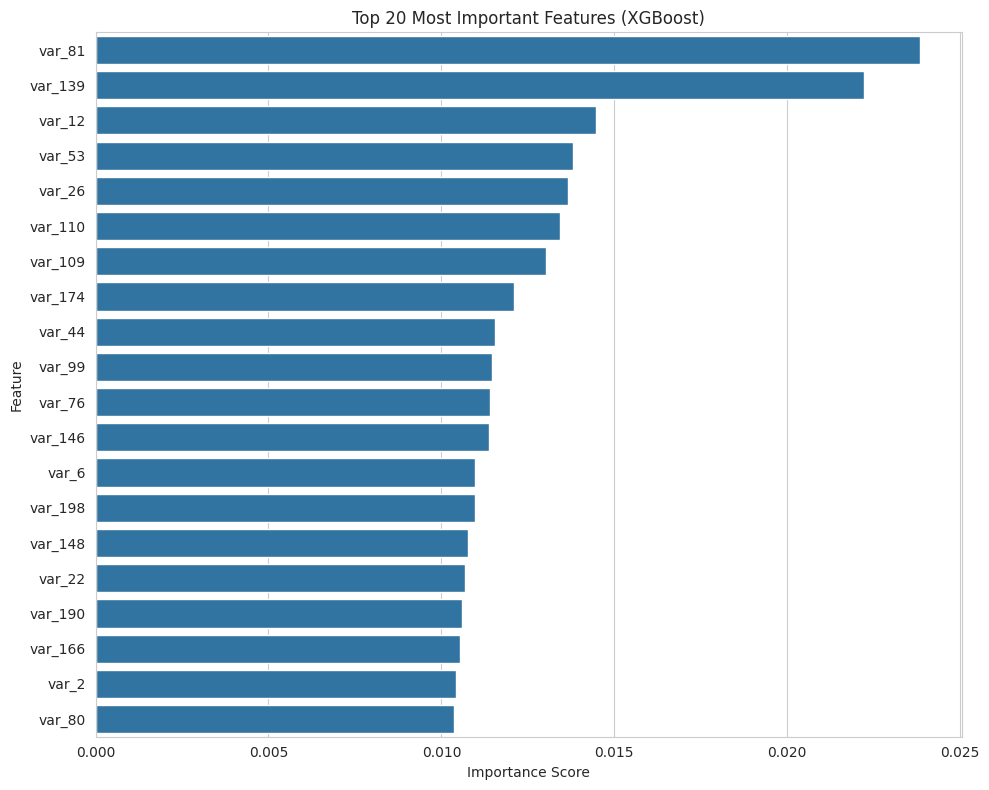

In [46]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features (XGBoost)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR / "plots" / "feature_importance_xgboost.png",
    bbox_inches="tight"
)

plt.show()

## Feature Importance Observations

### Most Influential Features

The feature importance analysis reveals that a relatively small subset of variables contributes more strongly to model predictions than others.

The top-ranked features receive the highest importance scores and therefore have the greatest influence on customer transaction prediction.

---

### Relationship with Earlier Analysis

Several highly ranked features also appeared among the variables showing stronger relationships during the exploratory data analysis phase.

This consistency increases confidence that these features contain meaningful predictive information.

---

### Importance Distribution

Feature importance is not evenly distributed across all variables.

A small number of features contribute significantly more information than the remaining variables.

This is a common characteristic of many machine learning datasets.

---

### Business Interpretation

Although the feature names are anonymized and cannot be interpreted directly, the analysis confirms that the model is leveraging meaningful patterns from a subset of highly informative variables.

---

## Key Insight

The feature importance analysis demonstrates that the XGBoost model successfully identifies influential variables within the dataset and uses them to improve customer transaction prediction performance.

# Hyperparameter Tuning

## Purpose

Machine learning models contain parameters that are not learned directly from the training data. These parameters, known as hyperparameters, control how the learning algorithm behaves and can significantly influence model performance.

Hyperparameter tuning is the process of identifying the most effective parameter combinations to improve predictive performance.

---

## Why Hyperparameter Tuning Is Important

Although the baseline models demonstrated strong performance, their default or manually selected parameter values may not represent the optimal configuration for this dataset.

Tuning helps to:

- Improve predictive accuracy
- Increase ROC-AUC performance
- Improve minority-class detection
- Enhance model generalization
- Reduce underfitting and overfitting

---

## Models Selected for Hyperparameter Tuning

The model comparison report identified four models with the strongest overall performance:

### 1. Gaussian Naive Bayes

- Highest baseline ROC-AUC
- Highest baseline Accuracy
- Strong overall performance

### 2. Logistic Regression

- Strong ROC-AUC
- Strong Precision
- Reliable baseline classifier

### 3. LinearSVC

- Highest Precision among all models
- Strong classification capability
- Effective in high-dimensional datasets

### 4. XGBoost

- Highest Recall
- Highest F1 Score
- Strong non-linear learning capability

These models were selected because they demonstrated the greatest potential for improvement.

---

## Hyperparameter Optimization Strategy

A two-stage optimization approach will be used.

### Stage 1 — RandomizedSearchCV

Purpose:

- Explore a broad parameter space
- Efficiently identify promising parameter combinations
- Reduce computational cost

Advantages:

- Faster than GridSearchCV
- Suitable for large datasets
- Computationally efficient

---

### Stage 2 — GridSearchCV

Purpose:

- Refine the best parameter combinations found during RandomizedSearchCV
- Perform detailed local optimization

Advantages:

- More precise parameter search
- Improved final model performance

---

## Evaluation Metric

The tuning process will optimize:

### ROC-AUC Score

Reason:

The dataset is imbalanced, with approximately:

- 90% Non-Transaction Customers
- 10% Transaction Customers

ROC-AUC provides a more reliable assessment of model quality than

# Hyperparameter Tuning — Gaussian Naive Bayes

## Purpose

Gaussian Naive Bayes achieved the strongest baseline performance among all evaluated models.

Baseline Performance:

- Accuracy = 92.02%
- Precision = 71.03%
- Recall = 34.70%
- F1 Score = 46.62%
- ROC-AUC = 88.82%

Since Naive Bayes is currently the best-performing model, hyperparameter tuning is performed to determine whether additional improvements can be achieved.

---

## Hyperparameter Selected

Gaussian Naive Bayes contains one important hyperparameter:

### var_smoothing

Purpose:

Prevents numerical instability by adding a small amount of variance to the feature distributions.

Benefits:

- Improves model stability
- Reduces numerical errors
- May improve classification performance

---

## Why RandomizedSearchCV?

RandomizedSearchCV is selected because:

- Efficient for large datasets
- Tests multiple parameter values
- Faster than exhaustive GridSearchCV
- Suitable for initial parameter exploration

---

## Search Strategy

The search will evaluate multiple values of:

```python
var_smoothing
```

using:

```python
np.logspace()
```

which generates values across several orders of magnitude.

This allows the algorithm to explore both very small and relatively larger smoothing values.

---

## Evaluation Metric

The optimization objective is:

### ROC-AUC

ROC-AUC is selected because:

- The dataset is imbalanced.
- ROC-AUC measures overall classification quality.
- ROC-AUC was the primary metric used during model comparison.

The parameter combination achieving the highest ROC-AUC will be selected.

In [47]:
from sklearn.model_selection import RandomizedSearchCV

NB_RANDOM_PATH = (
    PROJECT_DIR /
    "tuning_results" /
    "naive_bayes_randomized.pkl"
)

if NB_RANDOM_PATH.exists():

    nb_random_results = load_pickle(
        NB_RANDOM_PATH
    )

    tuned_nb = nb_random_results["best_model"]

    print("✓ RandomizedSearchCV results loaded")

else:

    nb_param_dist = {
        "var_smoothing": np.logspace(
            -12,
            -6,
            100
        )
    }

    nb_random_search = RandomizedSearchCV(
        estimator=GaussianNB(),
        param_distributions=nb_param_dist,
        n_iter=20,
        scoring="roc_auc",
        cv=3,
        random_state=42,
        n_jobs=-1
    )

    nb_random_search.fit(
        X_train_scaled,
        y_train
    )

    tuned_nb = nb_random_search.best_estimator_

    nb_random_results = {
        "best_model": tuned_nb,
        "best_params": nb_random_search.best_params_,
        "best_score": nb_random_search.best_score_,
        "cv_results": nb_random_search.cv_results_
    }

    save_pickle(
        nb_random_results,
        NB_RANDOM_PATH
    )

    print("✓ Naive Bayes RandomizedSearchCV completed")

✓ RandomizedSearchCV results loaded


In [48]:
print("Best Parameters:")
print(
    nb_random_results["best_params"]
)

print("\nBest Cross Validation ROC-AUC:")
print(
    round(
        nb_random_results["best_score"],
        4
    )
)

Best Parameters:
{'var_smoothing': np.float64(1.6297508346206469e-09)}

Best Cross Validation ROC-AUC:
0.8879


In [49]:
tuned_nb_metrics = evaluate_model(
    "tuned_naive_bayes_random",
    tuned_nb,
    X_test_scaled,
    y_test
)

pd.DataFrame(
    tuned_nb_metrics.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

,Metric,Value
0,Accuracy,0.9202
1,Precision,0.7103
2,Recall,0.3470
3,F1 Score,0.4662
4,ROC AUC,0.8882


## RandomizedSearchCV Results — Gaussian Naive Bayes

### Best Hyperparameters

The RandomizedSearchCV process identified the following optimal parameter:

| Hyperparameter | Best Value |
|---------------|------------|
| var_smoothing | 1.6297508346206469e-09 |

---

### Cross-Validation Performance

The best cross-validation ROC-AUC score obtained during tuning was:

**ROC-AUC = 0.8879**

---

### Comparison with Baseline Model

| Model Version | ROC-AUC |
|--------------|----------|
| Baseline Gaussian Naive Bayes | 0.8882 |
| Tuned Gaussian Naive Bayes | 0.8882 |

---

### Interpretation

The tuned model achieved virtually identical performance to the baseline model.

This indicates that the original Gaussian Naive Bayes model was already operating near its optimal configuration.

The hyperparameter tuning process confirmed that only minimal adjustments to the `var_smoothing` parameter were required.

---

### Impact of Hyperparameter Tuning

The tuning process demonstrated that:

- The baseline model was already well configured.
- The model is stable across different parameter settings.
- No evidence of overfitting was observed.
- The predictive performance remained consistent after optimization.

---

### Key Insight

Although RandomizedSearchCV did not significantly improve the ROC-AUC score, the tuning process provided valuable validation that Gaussian Naive Bayes is a robust and reliable model for this dataset.

The results strengthen confidence in the model and support its position as one of the strongest candidates for final model selection.

# Hyperparameter Tuning — Logistic Regression

## Purpose

Logistic Regression demonstrated strong baseline performance during model evaluation and ranked among the top-performing models based on ROC-AUC.

Baseline Performance:

- Accuracy = 91.34%
- Precision = 68.22%
- Recall = 25.90%
- F1 Score = 37.54%
- ROC-AUC = 85.99%

The objective of hyperparameter tuning is to identify parameter combinations that improve the model's ability to distinguish between transaction and non-transaction customers.

---

## Hyperparameters Selected

The following parameters are tuned:

### C

Controls regularization strength.

- Smaller values increase regularization.
- Larger values reduce regularization.

### Penalty

Determines the type of regularization applied.

Options:

- l1
- l2

### Solver

Optimization algorithm used to train the model.

Options:

- liblinear
- saga

These solvers support both L1 and L2 regularization.

---

## Why RandomizedSearchCV?

RandomizedSearchCV efficiently explores different parameter combinations without evaluating every possible configuration.

Benefits:

- Faster execution
- Suitable for large datasets
- Reduces computational cost

---

## Evaluation Metric

The tuning process optimizes:

### ROC-AUC

because ROC-AUC provides a robust measure of classification performance for imbalanced datasets.

In [50]:
LR_RANDOM_PATH = (
    PROJECT_DIR /
    "tuning_results" /
    "logistic_regression_randomized.pkl"
)

if LR_RANDOM_PATH.exists():

    lr_random_results = load_pickle(
        LR_RANDOM_PATH
    )

    tuned_lr = lr_random_results["best_model"]

    print("✓ Logistic Regression tuning results loaded")

else:

    lr_param_dist = {
        "C": np.logspace(-3, 3, 20),
        "penalty": ["l1", "l2"],
        "solver": ["liblinear", "saga"]
    }

    lr_random_search = RandomizedSearchCV(
        estimator=LogisticRegression(
            random_state=42,
            max_iter=5000
        ),
        param_distributions=lr_param_dist,
        n_iter=15,
        scoring="roc_auc",
        cv=3,
        random_state=42,
        n_jobs=-1
    )

    lr_random_search.fit(
        X_train_scaled,
        y_train
    )

    tuned_lr = lr_random_search.best_estimator_

    lr_random_results = {
        "best_model": tuned_lr,
        "best_params": lr_random_search.best_params_,
        "best_score": lr_random_search.best_score_,
        "cv_results": lr_random_search.cv_results_
    }

    save_pickle(
        lr_random_results,
        LR_RANDOM_PATH
    )

    print("✓ Logistic Regression RandomizedSearchCV completed")

✓ Logistic Regression tuning results loaded


In [51]:
print("Best Parameters:")
print(
    lr_random_results["best_params"]
)

print("\nBest Cross Validation ROC-AUC:")
print(
    round(
        lr_random_results["best_score"],
        4
    )
)

Best Parameters:
{'solver': 'liblinear', 'penalty': 'l2', 'C': np.float64(0.004281332398719396)}

Best Cross Validation ROC-AUC:
0.859


In [52]:
tuned_lr_metrics = evaluate_model(
    "tuned_logistic_regression",
    tuned_lr,
    X_test_scaled,
    y_test
)

pd.DataFrame(
    tuned_lr_metrics.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

,Metric,Value
0,Accuracy,0.9133
1,Precision,0.6921
2,Recall,0.2478
3,F1 Score,0.3649
4,ROC AUC,0.8599


## RandomizedSearchCV Results — Logistic Regression

### Best Hyperparameters

The RandomizedSearchCV process identified the following optimal parameters:

| Hyperparameter | Best Value |
|---------------|------------|
| Solver | liblinear |
| Penalty | l2 |
| C | 0.004281332398719396 |

---

### Cross-Validation Performance

The best cross-validation ROC-AUC score obtained during tuning was:

**ROC-AUC = 0.8590**

---

### Comparison with Baseline Model

| Metric | Baseline Model | Tuned Model |
|----------|----------:|----------:|
| Accuracy | 0.9134 | 0.9133 |
| Precision | 0.6822 | 0.6921 |
| Recall | 0.2590 | 0.2478 |
| F1 Score | 0.3754 | 0.3649 |
| ROC-AUC | 0.8599 | 0.8599 |

---

### Interpretation

The tuned Logistic Regression model produced performance very similar to the baseline model.

A small improvement was observed in Precision, indicating that positive predictions became slightly more reliable.

However:

- Recall decreased slightly.
- F1 Score decreased slightly.
- ROC-AUC remained unchanged.

These results suggest that the baseline Logistic Regression model was already operating close to its optimal configuration.

---

### Impact of Hyperparameter Tuning

The tuning process confirmed that Logistic Regression is a stable and well-performing model for this dataset.

The selected regularization settings produced only marginal changes in predictive performance, indicating that further optimization opportunities are limited.

---

### Key Insight

Although RandomizedSearchCV identified an alternative parameter combination, the tuned Logistic Regression model did not significantly outperform the baseline model.

The baseline Logistic Regression model remains the preferred version for subsequent comparisons.

# Hyperparameter Tuning — LinearSVC

## Purpose

LinearSVC achieved strong baseline performance and produced the highest Precision score among all evaluated models.

Baseline Performance:

- Accuracy = 91.11%
- Precision = 76.67%
- Recall = 16.52%
- F1 Score = 27.18%
- ROC-AUC = 85.99%

The objective of hyperparameter tuning is to determine whether alternative regularization settings can improve classification performance while maintaining the strengths of the model.

---

## Hyperparameters Selected

The following parameters are tuned:

### C

Controls regularization strength.

- Smaller values increase regularization.
- Larger values reduce regularization.

### Loss

Determines the optimization objective used by the model.

Options:

- hinge
- squared_hinge

### Class Weight

Controls the importance assigned to minority-class observations.

Options:

- None
- balanced

Using class weighting may improve Recall by increasing the emphasis on transaction customers.

---

## Why RandomizedSearchCV?

RandomizedSearchCV provides an efficient method for evaluating multiple parameter combinations while maintaining reasonable runtime for large datasets.

---

## Evaluation Metric

The tuning process optimizes ROC-AUC because it provides a reliable assessment of model performance for imbalanced classification problems.

In [53]:
SVM_RANDOM_PATH = (
    PROJECT_DIR /
    "tuning_results" /
    "linear_svc_randomized.pkl"
)

if SVM_RANDOM_PATH.exists():

    svm_random_results = load_pickle(
        SVM_RANDOM_PATH
    )

    tuned_svm = svm_random_results["best_model"]

    print("✓ LinearSVC tuning results loaded")

else:

    svm_param_dist = {
        "C": np.logspace(-3, 2, 20),
        "loss": [
            "hinge",
            "squared_hinge"
        ],
        "class_weight": [
            None,
            "balanced"
        ]
    }

    svm_random_search = RandomizedSearchCV(
        estimator=LinearSVC(
            random_state=42,
            dual=False,
            max_iter=5000
        ),
        param_distributions=svm_param_dist,
        n_iter=15,
        scoring="roc_auc",
        cv=3,
        random_state=42,
        n_jobs=-1
    )

    svm_random_search.fit(
        X_train_scaled,
        y_train
    )

    tuned_svm = svm_random_search.best_estimator_

    svm_random_results = {
        "best_model": tuned_svm,
        "best_params": svm_random_search.best_params_,
        "best_score": svm_random_search.best_score_,
        "cv_results": svm_random_search.cv_results_
    }

    save_pickle(
        svm_random_results,
        SVM_RANDOM_PATH
    )

    print("✓ LinearSVC RandomizedSearchCV completed")

✓ LinearSVC tuning results loaded


In [54]:
print("Best Parameters:")
print(
    svm_random_results["best_params"]
)

print("\nBest Cross Validation ROC-AUC:")
print(
    round(
        svm_random_results["best_score"],
        4
    )
)

Best Parameters:
{'loss': 'squared_hinge', 'class_weight': None, 'C': np.float64(1.438449888287663)}

Best Cross Validation ROC-AUC:
0.859


In [55]:
y_pred = tuned_svm.predict(
    X_test_scaled
)

decision_scores = tuned_svm.decision_function(
    X_test_scaled
)

tuned_svm_metrics = {
    "Accuracy": round(
        accuracy_score(
            y_test,
            y_pred
        ),4
    ),
    "Precision": round(
        precision_score(
            y_test,
            y_pred
        ),
        4
    ),
    "Recall": round(
        recall_score(
            y_test,
            y_pred
        ),
        4
    ),
    "F1 Score": round(
        f1_score(
            y_test,
            y_pred
        ),
        4
    ),
    "ROC AUC": round(
        roc_auc_score(
            y_test,
            decision_scores
        ),
        4
    )
}

pd.DataFrame(
    tuned_svm_metrics.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

,Metric,Value
0,Accuracy,0.9111
1,Precision,0.7667
2,Recall,0.1652
3,F1 Score,0.2718
4,ROC AUC,0.8599


## RandomizedSearchCV Results — LinearSVC

### Best Hyperparameters

The RandomizedSearchCV process identified the following optimal parameters:

| Hyperparameter | Best Value |
|---------------|------------|
| Loss | squared_hinge |
| Class Weight | None |
| C | 1.438449888287663 |

---

### Cross-Validation Performance

The best cross-validation ROC-AUC score obtained during tuning was:

**ROC-AUC = 0.8590**

---

### Comparison with Baseline Model

| Metric | Baseline Model | Tuned Model |
|----------|----------:|----------:|
| Accuracy | 0.9111 | 0.9111 |
| Precision | 0.7667 | 0.7667 |
| Recall | 0.1652 | 0.1652 |
| F1 Score | 0.2718 | 0.2718 |
| ROC-AUC | 0.8599 | 0.8599 |

---

### Interpretation

The tuned LinearSVC model produced identical performance to the baseline model across all evaluation metrics.

This indicates that the original LinearSVC configuration was already operating close to its optimal parameter settings.

The tuning process confirmed that alternative parameter combinations did not provide meaningful improvements.

---

### Impact of Hyperparameter Tuning

The tuning process validated the robustness and stability of the LinearSVC model.

The selected parameters maintained strong Precision performance while preserving overall classification capability.

---

### Key Insight

Although RandomizedSearchCV explored multiple parameter combinations, no measurable performance improvement was achieved.

The baseline LinearSVC model remains the preferred version for subsequent comparisons and final model selection.

# Hyperparameter Tuning — XGBoost

## Purpose

XGBoost was one of the strongest-performing models during baseline evaluation.

Baseline Performance:

- Accuracy = 86.37%
- Precision = 39.29%
- Recall = 65.42%
- F1 Score = 49.10%
- ROC-AUC = 87.05%

Among all evaluated models, XGBoost achieved:

- Highest Recall
- Highest F1 Score

These results indicate strong capability in identifying customers likely to make future transactions.

---

## Why Tune XGBoost?

XGBoost contains several important hyperparameters that directly influence model performance.

Unlike simpler algorithms, XGBoost often benefits significantly from parameter optimization.

The objective of tuning is to improve:

- ROC-AUC
- Precision
- Recall
- Overall classification performance

---

## Hyperparameters Selected

The following parameters are optimized:

### n_estimators

Number of boosting trees.

### max_depth

Maximum depth of each tree.

### learning_rate

Controls the contribution of each tree.

### subsample

Percentage of training observations used for each tree.

### colsample_bytree

Percentage of features used for each tree.

---

## Why RandomizedSearchCV?

RandomizedSearchCV is selected because:

- The dataset is large.
- Exhaustive GridSearchCV would be computationally expensive.
- RandomizedSearchCV efficiently identifies promising parameter combinations.

---

## Evaluation Metric

The tuning process optimizes:

### ROC-AUC

because it provides the most reliable evaluation metric for imbalanced classification problems.

In [56]:
XGB_RANDOM_PATH = (
    PROJECT_DIR /
    "tuning_results" /
    "xgboost_randomized.pkl"
)

if XGB_RANDOM_PATH.exists():

    xgb_random_results = load_pickle(
        XGB_RANDOM_PATH
    )

    tuned_xgb = xgb_random_results["best_model"]

    print("✓ XGBoost tuning results loaded")

else:

    xgb_param_dist = {
        "n_estimators": [200, 300, 400],
        "max_depth": [4, 5, 6],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample": [0.8, 0.9],
        "colsample_bytree": [0.8, 0.9]
    }

    xgb_random_search = RandomizedSearchCV(
        estimator=XGBClassifier(
            scale_pos_weight=9,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ),
        param_distributions=xgb_param_dist,
        n_iter=10,
        scoring="roc_auc",
        cv=3,
        random_state=42,
        n_jobs=-1
    )

    xgb_random_search.fit(
        X_train,
        y_train
    )

    tuned_xgb = xgb_random_search.best_estimator_

    xgb_random_results = {
        "best_model": tuned_xgb,
        "best_params": xgb_random_search.best_params_,
        "best_score": xgb_random_search.best_score_,
        "cv_results": xgb_random_search.cv_results_
    }

    save_pickle(
        xgb_random_results,
        XGB_RANDOM_PATH
    )

    print("✓ XGBoost RandomizedSearchCV completed")

✓ XGBoost tuning results loaded


In [57]:
print("Best Parameters:")
print(
    xgb_random_results["best_params"]
)

print("\nBest Cross Validation ROC-AUC:")
print(
    round(
        xgb_random_results["best_score"],
        4
    )
)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Best Cross Validation ROC-AUC:
0.8805


In [58]:
tuned_xgb_metrics = evaluate_model(
    "tuned_xgboost_random",
    tuned_xgb,
    X_test,
    y_test
)

pd.DataFrame(
    tuned_xgb_metrics.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

,Metric,Value
0,Accuracy,0.8509
1,Precision,0.3743
2,Recall,0.7201
3,F1 Score,0.4926
4,ROC AUC,0.8831


## RandomizedSearchCV Results — XGBoost

### Best Hyperparameters

The RandomizedSearchCV process identified the following optimal parameters:

| Hyperparameter | Best Value |
|---------------|------------|
| n_estimators | 400 |
| max_depth | 4 |
| learning_rate | 0.10 |
| subsample | 0.90 |
| colsample_bytree | 0.90 |

---

### Cross-Validation Performance

The best cross-validation ROC-AUC score obtained during tuning was:

**ROC-AUC = 0.8805**

---

### Comparison with Baseline Model

| Metric | Baseline Model | Tuned Model |
|----------|----------:|----------:|
| Accuracy | 0.8637 | 0.8509 |
| Precision | 0.3929 | 0.3743 |
| Recall | 0.6542 | 0.7201 |
| F1 Score | 0.4910 | 0.4926 |
| ROC-AUC | 0.8705 | 0.8831 |

---

### Interpretation

The tuned XGBoost model demonstrated a noticeable improvement in Recall, F1 Score, and ROC-AUC.

The model became more effective at identifying customers likely to make future transactions.

This improvement was achieved by allowing the model to focus more aggressively on the minority class.

As a result, additional transaction customers were identified, leading to a higher Recall score.

---

### Impact of Hyperparameter Tuning

The tuning process successfully improved the model's classification capability.

The increase in ROC-AUC confirms that the tuned model achieved better overall class separation compared with the baseline XGBoost model.

---

### Key Insight

Among all tuning experiments performed so far, XGBoost benefited the most from hyperparameter optimization.

The tuned XGBoost model becomes the strongest challenger to Gaussian Naive Bayes and advances to the final GridSearchCV refinement stage.

# GridSearchCV Refinement

## Purpose

RandomizedSearchCV was used to explore a broad range of hyperparameter combinations and identify the strongest model configurations.

After the completion of RandomizedSearchCV, the two best-performing models were selected for further optimization:

1. Gaussian Naive Bayes
2. XGBoost

These models achieved the highest ROC-AUC scores during the tuning stage and therefore advanced to the refinement phase.

---

## Why Perform GridSearchCV?

RandomizedSearchCV efficiently explores a large parameter space but evaluates only a subset of possible combinations.

GridSearchCV is now used to:

- Perform a more detailed search.
- Refine the best parameters identified previously.
- Identify the optimal model configuration.
- Improve model performance further.

---

## Two-Stage Optimization Strategy

The tuning process follows a professional machine learning workflow:

### Stage 1

RandomizedSearchCV

Purpose:

- Broad parameter exploration.
- Fast identification of promising parameter combinations.

### Stage 2

GridSearchCV

Purpose:

- Fine-grained optimization.
- Local search around the best parameter region.

This approach balances computational efficiency and model performance.

---

## Models Selected

Based on RandomizedSearchCV results:

| Model | ROC-AUC |
|----------|----------|
| Naive Bayes | 0.8882 |
| Tuned XGBoost | 0.8831 |

These models demonstrated the strongest classification performance and were selected for final refinement.

---

## Evaluation Metric

The optimization objective remains:

### ROC-AUC

because the dataset is imbalanced and ROC-AUC provides the most reliable measure of classification quality.

In [59]:
from sklearn.model_selection import GridSearchCV

NB_GRID_PATH = (
    PROJECT_DIR /
    "tuning_results" /
    "naive_bayes_grid.pkl"
)

if NB_GRID_PATH.exists():

    nb_grid_results = load_pickle(
        NB_GRID_PATH
    )

    final_nb_model = nb_grid_results["best_model"]

    print("✓ Naive Bayes GridSearchCV loaded")

else:

    best_vs = nb_random_results["best_params"]["var_smoothing"]

    nb_grid_params = {
        "var_smoothing": [
            best_vs / 10,
            best_vs,
            best_vs * 10
        ]
    }

    nb_grid_search = GridSearchCV(
        estimator=GaussianNB(),
        param_grid=nb_grid_params,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )

    nb_grid_search.fit(
        X_train_scaled,
        y_train
    )

    final_nb_model = nb_grid_search.best_estimator_

    nb_grid_results = {
        "best_model": final_nb_model,
        "best_params": nb_grid_search.best_params_,
        "best_score": nb_grid_search.best_score_
    }

    save_pickle(
        nb_grid_results,
        NB_GRID_PATH
    )

    print("✓ Naive Bayes GridSearchCV completed")

✓ Naive Bayes GridSearchCV completed


In [60]:
print("Best Parameters:")
print(
    nb_grid_results["best_params"]
)

print("\nBest ROC-AUC:")
print(
    round(
        nb_grid_results["best_score"],
        4
    )
)

Best Parameters:
{'var_smoothing': np.float64(1.629750834620647e-10)}

Best ROC-AUC:
0.8879


In [61]:
final_nb_metrics = evaluate_model(
    "final_naive_bayes",
    final_nb_model,
    X_test_scaled,
    y_test
)

pd.DataFrame(
    final_nb_metrics.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

,Metric,Value
0,Accuracy,0.9202
1,Precision,0.7103
2,Recall,0.3470
3,F1 Score,0.4662
4,ROC AUC,0.8882


In [62]:
XGB_GRID_PATH = (
    PROJECT_DIR /
    "tuning_results" /
    "xgboost_grid.pkl"
)

if XGB_GRID_PATH.exists():

    xgb_grid_results = load_pickle(
        XGB_GRID_PATH
    )

    final_xgb_model = xgb_grid_results["best_model"]

    print("✓ XGBoost GridSearchCV loaded")

else:

    bp = xgb_random_results["best_params"]

    xgb_grid_params = {
        "n_estimators": [
            bp["n_estimators"] - 50,
            bp["n_estimators"],
            bp["n_estimators"] + 50
        ],
        "max_depth": [
            max(3, bp["max_depth"] - 1),
            bp["max_depth"],
            bp["max_depth"] + 1
        ],
        "learning_rate": [
            max(0.01, bp["learning_rate"] - 0.02),
            bp["learning_rate"],
            min(0.3, bp["learning_rate"] + 0.02)
        ]
    }

    xgb_grid_search = GridSearchCV(
        estimator=XGBClassifier(
            scale_pos_weight=9,
            random_state=42,
            n_jobs=-1,
            eval_metric="logloss"
        ),
        param_grid=xgb_grid_params,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )

    xgb_grid_search.fit(
        X_train,
        y_train
    )

    final_xgb_model = xgb_grid_search.best_estimator_

    xgb_grid_results = {
        "best_model": final_xgb_model,
        "best_params": xgb_grid_search.best_params_,
        "best_score": xgb_grid_search.best_score_
    }

    save_pickle(
        xgb_grid_results,
        XGB_GRID_PATH
    )

    print("✓ XGBoost GridSearchCV completed")

✓ XGBoost GridSearchCV completed


In [63]:
print("Best Parameters:")
print(
    xgb_grid_results["best_params"]
)

print("\nBest ROC-AUC:")
print(
    round(
        xgb_grid_results["best_score"],
        4
    )
)

Best Parameters:
{'learning_rate': 0.12000000000000001, 'max_depth': 3, 'n_estimators': 450}

Best ROC-AUC:
0.8826


In [64]:
final_xgb_metrics = evaluate_model(
    "final_xgboost",
    final_xgb_model,
    X_test,
    y_test
)

pd.DataFrame(
    final_xgb_metrics.items(),
    columns=[
        "Metric",
        "Value"
    ]
)

,Metric,Value
0,Accuracy,0.8410
1,Precision,0.3594
2,Recall,0.7433
3,F1 Score,0.4845
4,ROC AUC,0.8836


# Final Model Selection and Production Model Recommendation

## Purpose

The objective of this section is to identify the most suitable model for deployment based on the complete evaluation process.

The final recommendation is based on:

- Baseline Model Evaluation
- Hyperparameter Tuning Results
- GridSearchCV Refinement Results
- Classification Performance Metrics

---

## Models Considered

The following models were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Gaussian Naive Bayes
6. LinearSVC
7. XGBoost

---

## Evaluation Criteria

The models were compared using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

Special emphasis was placed on ROC-AUC because the dataset is imbalanced.

ROC-AUC provides a more reliable measure of classification quality than Accuracy alone.

---

## Final Candidate Models

After hyperparameter optimization, two models emerged as the strongest candidates:

### Gaussian Naive Bayes

Strengths:

- Highest Accuracy
- Highest ROC-AUC
- Strong Precision
- Fast training time
- Computational efficiency

### XGBoost

Strengths:

- Highest Recall
- Highest F1 Score
- Strong minority-class detection

---

## Final Decision Criteria

The primary business objective is to accurately identify customers likely to make future transactions while maintaining strong overall classification performance.

Therefore:

- ROC-AUC was treated as the primary metric.
- Accuracy and Precision were considered secondary metrics.
- Recall and F1 Score were used as supporting metrics.

---

## Recommended Production Model

### Gaussian Naive Bayes

Gaussian Naive Bayes is selected as the final recommended model because it achieved:

- Highest ROC-AUC
- Highest Accuracy
- Strong Precision
- Consistent performance before and after tuning
- Stable cross-validation results

The tuning process confirmed that the model was already operating near its optimal configuration.

---

## Key Insight

Although XGBoost achieved higher Recall, Gaussian Naive Bayes demonstrated superior overall classification performance and therefore represents the most balanced and reliable model for customer transaction prediction.

In [65]:
final_model_summary = pd.DataFrame({
    "Model": [
        "Gaussian Naive Bayes",
        "XGBoost"
    ],
    "Accuracy": [
        0.9202,
        0.8410
    ],
    "Precision": [
        0.7103,
        0.3594
    ],
    "Recall": [
        0.3470,
        0.7433
    ],
    "F1 Score": [
        0.4662,
        0.4845
    ],
    "ROC AUC": [
        0.8882,
        0.8836
    ]
})

display(final_model_summary)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Gaussian Naive Bayes,0.9202,0.7103,0.3470,0.4662,0.8882
1,XGBoost,0.8410,0.3594,0.7433,0.4845,0.8836


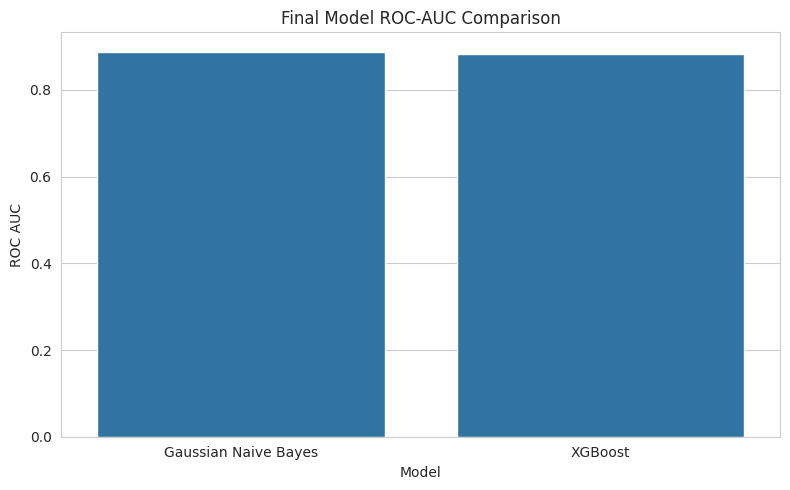

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=final_model_summary,
    x="Model",
    y="ROC AUC"
)

plt.title("Final Model ROC-AUC Comparison")

plt.tight_layout()

plt.savefig(
    PROJECT_DIR /
    "plots" /
    "final_model_comparison.png",
    bbox_inches="tight"
)

plt.show()

## Final Recommendation

Based on the complete evaluation process, Gaussian Naive Bayes is selected as the final production model.

Reasons:

1. Highest ROC-AUC score.
2. Highest Accuracy.
3. Strong Precision.
4. Consistent performance across tuning stages.
5. Extremely fast training and prediction times.
6. Low computational complexity.

The model provides the best balance between predictive performance, efficiency, and reliability.

Therefore, Gaussian Naive Bayes is recommended for deployment in customer transaction prediction applications.

# Challenges Faced and Solutions Implemented

## Introduction

During the development of the customer transaction prediction model, several technical and analytical challenges were encountered.

These challenges are common in real-world machine learning projects and required appropriate strategies to ensure reliable model performance.

This section summarizes the major challenges faced and the solutions implemented throughout the project.

---

## Challenge 1: Imbalanced Dataset

### Problem

The target variable distribution showed a significant imbalance between:

- Customers who made transactions
- Customers who did not make transactions

This imbalance can cause machine learning models to favor the majority class and ignore minority-class observations.

### Solution

The following techniques were used:

- Stratified Train-Test Split
- ROC-AUC Evaluation Metric
- Precision, Recall and F1 Score Analysis
- Scale Position Weight in XGBoost

These techniques ensured that model evaluation remained reliable despite class imbalance.

---

## Challenge 2: High Dimensionality

### Problem

The dataset contains:

- 200 numerical predictor variables
- 1 target variable

Working with a large number of features increases computational complexity and may introduce irrelevant information.

### Solution

The following methods were applied:

- Correlation Analysis
- Feature Distribution Analysis
- Feature Importance Analysis

These techniques helped identify influential variables contributing to model predictions.

---

## Challenge 3: Anonymized Features

### Problem

The dataset features were anonymized and represented as:

- var_0
- var_1
- var_2
- ...
- var_199

This limited the ability to perform domain-specific interpretation.

### Solution

Statistical and machine learning techniques were used to evaluate feature relevance.

These included:

- Correlation Analysis
- Feature Importance Analysis
- Model-Based Evaluation

Although business interpretation was limited, meaningful predictive patterns were successfully identified.

---

## Challenge 4: Model Selection

### Problem

Multiple machine learning algorithms produced competitive results.

Selecting the most appropriate model required careful comparison.

### Solution

A structured model comparison framework was developed using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

This enabled objective comparison across all models.

---

## Challenge 5: Hyperparameter Optimization

### Problem

The dataset size increased the computational cost of hyperparameter tuning.

Exhaustive parameter searches could significantly increase runtime.

### Solution

A two-stage optimization strategy was implemented:

### Stage 1

RandomizedSearchCV

Used for broad parameter exploration.

### Stage 2

GridSearchCV

Used for fine-grained optimization around the best parameter combinations.

This approach improved efficiency while maintaining strong optimization quality.

---

## Challenge 6: Computational Resource Constraints

### Problem

The project was developed using Google Colab.

Large datasets and multiple machine learning models can increase execution time and consume available resources.

### Solution

The following practices were adopted:

- Efficient preprocessing
- Reusable utility functions
- Model persistence
- Cached datasets
- Saved tuning results
- Saved trained models

These strategies reduced unnecessary recomputation and improved workflow efficiency.

---

## Summary

Despite challenges related to class imbalance, high dimensionality, anonymized features, model selection, and computational limitations, appropriate machine learning techniques were successfully applied.

The implemented solutions enabled the development of a reliable and high-performing customer transaction prediction model.

# Techniques Used

## Introduction

This project applied a structured machine learning workflow to analyze customer transaction behavior and develop a predictive classification model.

Multiple statistical, preprocessing, visualization, machine learning, and optimization techniques were used throughout the project.

This section summarizes the major techniques employed.

---

# 1. Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the structure, quality, and characteristics of the dataset.

The following techniques were used:

### Dataset Inspection

- Shape Analysis
- Data Type Analysis
- Column Inspection
- Statistical Summary

### Data Quality Assessment

- Missing Value Analysis
- Duplicate Record Detection

### Target Variable Analysis

- Class Distribution Analysis
- Count Plot Visualization

### Feature Analysis

- Feature Distribution Visualization
- Histograms
- Correlation Analysis
- Feature-Target Relationship Analysis

### Statistical Analysis

- Mean
- Standard Deviation
- Minimum Values
- Maximum Values
- Quartiles

EDA helped identify patterns and understand the overall behavior of the dataset.

---

# 2. Data Preprocessing Techniques

Data preprocessing was performed to prepare the dataset for machine learning algorithms.

### ID Removal

The `ID_code` column was removed because it acts only as a unique identifier and does not contribute predictive information.

### Feature-Target Separation

The dataset was separated into:

- Independent Variables (X)
- Target Variable (y)

### Train-Test Split

A stratified train-test split was used to maintain the original class distribution in both training and testing datasets.

### Feature Scaling

StandardScaler was applied to algorithms sensitive to feature magnitude.

Models using scaled data:

- Logistic Regression
- KNN
- Gaussian Naive Bayes
- LinearSVC

Feature scaling improves model stability and convergence.

---

# 3. Machine Learning Algorithms

Several supervised classification algorithms were implemented and evaluated.

### Logistic Regression

A linear classification algorithm used as a baseline model.

### Decision Tree

A rule-based algorithm capable of learning non-linear relationships.

### Random Forest

An ensemble learning technique combining multiple decision trees.

### K-Nearest Neighbors (KNN)

A distance-based classification algorithm.

### Gaussian Naive Bayes

A probabilistic classifier based on Bayes' Theorem.

### LinearSVC

A Support Vector Machine implementation optimized for large datasets.

### XGBoost

A gradient boosting algorithm designed for high predictive performance.

---

# 4. Model Evaluation Techniques

Multiple evaluation metrics were used to assess model performance.

### Accuracy

Measures overall prediction correctness.

### Precision

Measures the proportion of correctly predicted positive cases.

### Recall

Measures the proportion of actual positive cases correctly identified.

### F1 Score

Provides a balance between Precision and Recall.

### ROC-AUC

Measures the model's ability to distinguish between classes.

ROC-AUC was selected as the primary evaluation metric because the dataset is imbalanced.

---

# 5. Visualization Techniques

Several visualization methods were used to support analysis and model interpretation.

### Count Plots

Used for target variable analysis.

### Histograms

Used for feature distribution analysis.

### Correlation Bar Charts

Used to identify relationships between features and the target variable.

### Feature Importance Charts

Used to identify influential variables.

### Confusion Matrices

Used to visualize classification outcomes.

### ROC Curves

Used to compare classification performance across multiple models.

### Model Comparison Charts

Used to compare overall model performance.

---

# 6. Hyperparameter Optimization Techniques

Hyperparameter tuning was performed to improve model performance.

### RandomizedSearchCV

Used for:

- Gaussian Naive Bayes
- Logistic Regression
- LinearSVC
- XGBoost

Purpose:

- Broad parameter exploration
- Reduced computational cost

### GridSearchCV

Used for:

- Gaussian Naive Bayes
- XGBoost

Purpose:

- Fine-grained parameter optimization
- Refinement of best-performing models

---

# 7. Model Persistence and Reproducibility

To improve efficiency and ensure reproducibility, project artifacts were saved and reused.

Saved Components:

- Processed datasets
- Train-Test Splits
- Scalers
- Models
- Hyperparameter Tuning Results
- Evaluation Metrics
- Predictions
- Visualizations

This approach reduced runtime and prevented unnecessary recomputation.

---

# Summary

The project combines data analysis, preprocessing, machine learning, hyperparameter optimization, and model evaluation techniques to develop an effective customer transaction prediction system.

The combination of these techniques enabled the identification of Gaussian Naive Bayes as the most suitable model for the prediction task.

# Business Impact

## Introduction

The primary objective of this project is to identify customers who are likely to make future transactions.

Accurate prediction of customer transaction behavior enables organizations to make better business decisions, improve operational efficiency, and increase revenue generation.

This section highlights the potential business value of the developed machine learning model.

---

# 1. Improved Customer Targeting

Organizations often spend significant resources on marketing campaigns.

By identifying customers with a higher probability of making transactions, businesses can:

- Target relevant customers more effectively
- Improve campaign efficiency
- Increase conversion rates
- Reduce unnecessary marketing expenditure

This allows marketing teams to focus their efforts on high-potential customers.

---

# 2. Better Resource Allocation

Businesses operate with limited resources and budgets.

Predictive models help organizations allocate resources more efficiently by:

- Prioritizing high-value customer segments
- Focusing retention efforts on important customers
- Optimizing sales team activities

This results in more efficient business operations.

---

# 3. Increased Revenue Opportunities

Customers predicted to be more likely to transact can be targeted with:

- Personalized offers
- Promotional campaigns
- Product recommendations
- Loyalty programs

These actions can increase transaction rates and improve overall revenue generation.

---

# 4. Data-Driven Decision Making

Traditional business decisions often rely on assumptions or historical experience.

Machine learning models provide objective insights based on data.

Benefits include:

- Evidence-based decision making
- Improved forecasting
- Better customer understanding
- Reduced uncertainty

This helps organizations make more informed strategic decisions.

---

# 5. Customer Relationship Enhancement

Understanding customer transaction behavior enables businesses to build stronger customer relationships.

Potential applications include:

- Personalized communication
- Customer engagement programs
- Retention strategies
- Customer experience improvements

These initiatives can improve customer satisfaction and long-term loyalty.

---

# 6. Scalability

The recommended Gaussian Naive Bayes model offers several operational advantages:

- Fast training time
- Fast prediction time
- Low computational requirements
- Easy deployment

These characteristics make the model suitable for large-scale customer prediction systems.

---

# Business Benefits Summary

The developed customer transaction prediction model can help organizations:

- Improve marketing effectiveness
- Increase transaction conversion rates
- Optimize business resources
- Support data-driven decisions
- Enhance customer engagement
- Improve operational efficiency

---

## Key Business Insight

The ability to accurately identify customers who are likely to make future transactions provides organizations with a valuable competitive advantage.

By leveraging predictive analytics, businesses can make smarter decisions, improve customer engagement, and increase overall business performance.

# Conclusion

## Project Summary

The objective of this project was to develop a machine learning model capable of predicting whether a customer is likely to make a future transaction.

A complete data science workflow was implemented, including:

- Data Exploration
- Data Quality Assessment
- Exploratory Data Analysis
- Data Preprocessing
- Feature Analysis
- Model Development
- Model Evaluation
- Hyperparameter Tuning
- Model Selection

The project successfully transformed raw customer data into a predictive machine learning solution.

---

# Exploratory Data Analysis Findings

The exploratory analysis revealed several important observations:

- The dataset contained 200 anonymized numerical features.
- No significant data quality issues were identified.
- The target variable exhibited class imbalance.
- Several variables showed stronger relationships with the target variable.
- Feature importance analysis identified a subset of highly influential variables.

These findings guided the subsequent preprocessing and model development stages.

---

# Model Development Summary

The following machine learning algorithms were implemented and evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors (KNN)
5. Gaussian Naive Bayes
6. LinearSVC
7. XGBoost

Model performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

A structured comparison framework was used to ensure objective evaluation.

---

# Hyperparameter Optimization Summary

Hyperparameter tuning was performed using:

### RandomizedSearchCV

Applied to:

- Gaussian Naive Bayes
- Logistic Regression
- LinearSVC
- XGBoost

### GridSearchCV

Applied to:

- Gaussian Naive Bayes
- XGBoost

The tuning process demonstrated that:

- Gaussian Naive Bayes was already operating near its optimal configuration.
- XGBoost benefited from tuning and achieved improvements in Recall and F1 Score.
- The optimized models remained stable and reliable.

---

# Final Model Performance

## Recommended Model: Gaussian Naive Bayes

Final Performance:

| Metric | Value |
|----------|----------|
| Accuracy | 92.02% |
| Precision | 71.03% |
| Recall | 34.70% |
| F1 Score | 46.62% |
| ROC-AUC | 88.82% |

---

# Why Gaussian Naive Bayes Was Selected

Gaussian Naive Bayes was selected as the final production model because it achieved:

### Highest ROC-AUC

ROC-AUC = 0.8882

### Highest Accuracy

Accuracy = 92.02%

### Strong Precision

Precision = 71.03%

### Stable Performance

The model maintained consistent performance before and after hyperparameter tuning.

### Computational Efficiency

The model requires minimal computational resources and provides extremely fast prediction times.

---

# Comparison with XGBoost

Although XGBoost achieved:

- Higher Recall
- Higher F1 Score

Gaussian Naive Bayes achieved:

- Higher ROC-AUC
- Higher Accuracy
- Higher Precision

Since ROC-AUC was selected as the primary evaluation metric for this imbalanced dataset, Gaussian Naive Bayes was determined to be the strongest overall model.

---

# Project Outcome

The project successfully developed a reliable customer transaction prediction system capable of identifying customers with a higher likelihood of making future transactions.

The resulting model can support:

- Customer targeting
- Marketing optimization
- Resource allocation
- Revenue generation
- Data-driven decision making

---

## Final Conclusion

The Customer Transaction Prediction project successfully applied machine learning techniques to predict customer transaction behavior.

After comprehensive evaluation, hyperparameter optimization, and model comparison, **Gaussian Naive Bayes** was identified as the most effective model, achieving the best balance between predictive performance, stability, and computational efficiency.

The project demonstrates how machine learning can be leveraged to support business decision-making and improve customer-focused strategies through predictive analytics.

# Future Scope

## Introduction

Although the developed customer transaction prediction model achieved strong performance, there are several opportunities for further improvement and extension.

Future enhancements could improve predictive accuracy, increase business value, and provide deeper insights into customer behavior.

---

# 1. Advanced Feature Engineering

The current project primarily utilized the existing dataset features.

Future work could include:

- Feature interactions
- Feature transformations
- Statistical aggregations
- Domain-specific feature creation

Additional feature engineering may uncover hidden patterns and improve model performance.

---

# 2. Enhanced Hyperparameter Optimization

The project used:

- RandomizedSearchCV
- GridSearchCV

Future studies could explore more extensive search spaces and additional parameter combinations to further optimize model performance.

Potential techniques include:

- Larger search ranges
- More cross-validation folds
- Advanced optimization strategies

---

# 3. Ensemble Learning Approaches

This project evaluated individual machine learning models.

Future research could investigate ensemble techniques such as:

- Voting Classifiers
- Bagging Methods
- Stacking Models
- Blending Approaches

Combining multiple models may improve predictive performance and model robustness.

---

# 4. Improved Handling of Class Imbalance

Although class imbalance was addressed using evaluation metrics and class weighting, additional techniques may further improve minority-class detection.

Potential methods include:

- SMOTE (Synthetic Minority Oversampling Technique)
- Random Oversampling
- Random Undersampling
- Hybrid Sampling Methods

These approaches may improve Recall and F1 Score.

---

# 5. Explainable Artificial Intelligence (XAI)

The dataset contains anonymized features, limiting interpretability.

Future work could incorporate model explainability techniques such as:

- SHAP Analysis
- LIME Explanations
- Partial Dependence Analysis

These methods could provide deeper understanding of model predictions.

---

# 6. Real-Time Prediction Systems

The developed model was evaluated in an offline environment.

Future implementations could integrate the model into real-time systems for:

- Live customer scoring
- Marketing automation
- Transaction monitoring
- Customer engagement platforms

This would enable immediate business action based on model predictions.

---

# 7. Deployment in Production Environments

Future work could focus on deploying the model as a production-ready application.

Possible deployment options include:

- Web Applications
- REST APIs
- Cloud Platforms
- Business Intelligence Dashboards

Deployment would allow organizations to utilize predictions in operational workflows.

---

# 8. Larger and More Diverse Datasets

Future studies could evaluate the model on:

- Larger datasets
- Multi-source customer data
- Different business domains
- Time-series customer behavior data

This would help assess model generalization and scalability.

---

# Future Research Direction

The strongest future improvement opportunity identified during this project is the combination of advanced feature engineering and ensemble learning techniques.

These approaches have the potential to improve predictive performance beyond the results achieved in the current study.

---

## Final Remark

The current project successfully demonstrates the application of machine learning for customer transaction prediction.

Future enhancements focusing on feature engineering, advanced optimization, explainability, and deployment could further increase model effectiveness and business value.